# Phase 3: Data Collection and Exploratory Data Analysis
**CS 5304 | Spring 2026**

**Team Members:**
- Hongyiming Cui
- Xiaohui Zang
- Jiawei Wang
- George Zhu

## GitHub Repository Link: 

https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project

## Research Question

**Primary question:** To what extent does the socioeconomic gradient — measured by state-level median household income — explain variation in chronic disease mortality (heart disease and diabetes) across U.S. states in 2024?

**Secondary question:** How much of the income–mortality relationship is mediated by health behaviors (obesity, smoking, physical inactivity), versus income acting as an independent predictor?

We focus on state-level cross-sectional data for 2024 because our datasets lack monthly granularity, making a cross-sectional design more appropriate than a short panel. The unit of analysis is the U.S. state (+ D.C.), giving us 51 observations.

---
## Data Description

We use **nine datasets**, all from publicly available 2024 sources. All datasets are at the **U.S. state level** (50 states + D.C.) and were merged into a single cross-sectional file: `final_state_health_dataset_2024.csv`. Below we describe each source.

---

### 1. Income_2024.csv
- **Why:** Median household income is our primary independent variable (the socioeconomic gradient).
- **Observations/columns:** One row per geographic unit (states + national); columns are income statistics broken out by household type (wide format).
- **Columns used:** `Median income (dollars) > Households > Estimate` for each state.
- **Source:** U.S. Census Bureau, American Community Survey (ACS) 2024 1-Year Estimates.
- **Why created:** ACS is the primary federal survey for tracking economic and social characteristics of the U.S. population, funded by the federal government.
- **Preprocessing:** Dataset was in wide format with states as column headers. We extracted the median income row, parsed state names from column headers, removed commas, and converted to numeric.
- **Raw data:** [Census ACS Tables](https://data.census.gov/)

---

### 2. Heart_Disease_2024.csv
- **Why:** Heart disease death rate is one of our two primary dependent variables.
- **Observations/columns:** One row per state; key column is `Heart Disease Death Rate per 100,000`.
- **Source:** KFF (Kaiser Family Foundation) State Health Facts, 2024.
- **Why created:** KFF compiles state health data to support health policy analysis.
- **Preprocessing:** Skipped 2 metadata rows; filtered to 51 valid states; converted to numeric.
- **Raw data:** [KFF State Health Facts](https://www.kff.org/state-category/health-status/)

---

### 3. Diabetes_2024.csv
- **Why:** Diabetes death rate is our second primary dependent variable.
- **Observations/columns:** One row per state; key column is `Diabetes Death Rate per 100,000 Population`.
- **Source:** KFF State Health Facts, 2024.
- **Preprocessing:** Same structure as Heart Disease; same cleaning steps applied.
- **Raw data:** [KFF State Health Facts](https://www.kff.org/state-category/health-status/)

---

### 4. Diabetes_prevalence_2024.csv
- **Why:** Prevalence (% adults diagnosed) complements the mortality rate and lets us distinguish between disease burden and disease fatality.
- **Observations/columns:** One row per state; key column is `Yes` (proportion reporting diabetes diagnosis).
- **Source:** KFF State Health Facts, 2024.
- **Preprocessing:** Same as above.
- **Raw data:** [KFF State Health Facts](https://www.kff.org/state-category/health-status/)

---

### 5. Obesity_2024.csv
- **Why:** Obesity is a major risk factor for both heart disease and diabetes and may mediate the income–mortality relationship.
- **Observations/columns:** One row per state; we combined two columns: `Obese (BMI 30-39.9)` and `Severely Obese (BMI ≥ 40)` to get total obesity rate.
- **Source:** KFF State Health Facts, 2024.
- **Preprocessing:** Summed the two obesity columns; filtered to 51 states.
- **Raw data:** [KFF State Health Facts](https://www.kff.org/state-category/health-status/)

---

### 6. Smoking_2024.csv
- **Why:** Smoking is a well-established risk factor for chronic disease and correlates with lower income.
- **Observations/columns:** One row per state; key column is `All Adults` (proportion who smoke).
- **Source:** KFF State Health Facts, 2024.
- **Preprocessing:** Same standard cleaning function.
- **Raw data:** [KFF State Health Facts](https://www.kff.org/state-category/health-status/)

---

### 7. Physical_activity_2024.csv
- **Why:** Physical inactivity is a behavioral risk factor for chronic disease; higher-income states may have better infrastructure for physical activity.
- **Observations/columns:** One row per state; key column is `All Adults` (proportion meeting activity guidelines).
- **Source:** KFF State Health Facts, 2024.
- **Preprocessing:** Same standard cleaning function.
- **Raw data:** [KFF State Health Facts](https://www.kff.org/state-category/health-status/)

---

### 8. Health_Status_2024.csv
- **Why:** Self-reported poor health is a general indicator of population wellbeing, useful for understanding the broader health context of each state.
- **Observations/columns:** One row per state; key column is `Poor` (proportion reporting poor/fair health).
- **Source:** KFF State Health Facts, 2024.
- **Preprocessing:** Same standard cleaning function.
- **Raw data:** [KFF State Health Facts](https://www.kff.org/state-category/health-status/)

---

### 9. Uninsured_People_2024.csv
- **Why:** Insurance coverage is a potential confounder — uninsured individuals may have worse health outcomes and lower incomes.
- **Observations/columns:** One row per state; key column is `Adults 19-64` (proportion uninsured).
- **Source:** KFF State Health Facts, 2024.
- **Preprocessing:** Same standard cleaning function.
- **Raw data:** [KFF State Health Facts](https://www.kff.org/state-category/health-status/)

---

**Datasets not used:** Education_attainment_2024.csv, Employment_status_2024.csv, and Poverty_status_2024.csv were initially explored but did not contain state-level data in a compatible format and were excluded.

---
## Data Collection & Cleaning

All raw data were downloaded from KFF State Health Facts and the U.S. Census Bureau (ACS 2024). Each file was inspected individually before cleaning. Some datasets included 2–3 rows of metadata at the top, which were skipped using `skiprows=2`. The income dataset was in wide format (states as columns), requiring a custom reshape step.

To standardize the workflow, we wrote a general `clean_simple_file()` function that: (1) loads the file, (2) strips whitespace from column names, (3) keeps only the `Location` and target variable columns, (4) filters to the 51 valid state/DC observations, (5) renames columns, and (6) converts values to numeric. Datasets with non-standard structure (income, obesity) were handled with custom code. All datasets were merged using an inner join on `State`.

**Changes from Phase 1:** In Phase 1, we used a four-year panel dataset. After TA feedback noting that a short panel is not ideal for econometric analysis, we switched to a single-year cross-sectional design using 2024 data only. We also expanded the dataset from 3 variables to 9 variables by adding smoking, physical activity, uninsured rate, self-reported poor health, and diabetes prevalence. Three candidate datasets (education, employment, poverty) were explored but dropped due to incompatible geographic resolution.

**Full cleaning code:** See the Data Collection and Cleaning section below (this notebook).

---
# Data Collection and Cleaning

In [51]:
import pandas as pd

### Step 1: Load and inspect the raw datasets

We begin by loading each raw CSV to understand its structure. Some files contain a `Location` column with one row per state; others (income) use a wide format with states as column headers. We note which datasets are incompatible with state-level analysis.

In [52]:
# Inspect Diabetes mortality dataset
# skiprows=2 skips the metadata header rows common in KFF files
df = pd.read_csv("health_data/Diabetes_2024.csv", skiprows=2)
print(f"Shape: {df.shape}")
df.head()

Shape: (60, 4)


,Location,Number of Diabetes Deaths,"Diabetes Death Rate per 100,000 Population",Footnotes
0,United States,94445.0,21.7,1.0
1,Alabama,1485.0,22.4,NaN
2,Alaska,172.0,21.9,NaN
3,Arizona,2440.0,23.8,NaN
4,Arkansas,1253.0,31.9,NaN


In [53]:
# Inspect Diabetes prevalence dataset
df = pd.read_csv("new_dataset/Diabetes_prevalence_2024.csv", skiprows=2)
print(f"Shape: {df.shape}")
df.head()

Shape: (67, 6)


,Location,Yes,"Yes, Pregnancy-Related",No,"No, Pre-Diabetes or Borderline Diabetes",Footnotes
0,United States,0.125,0.008,0.840,0.026,1.0
1,Alabama,0.151,0.009,0.814,0.027,NaN
2,Alaska,0.094,0.012,0.874,0.021,NaN
3,Arizona,0.115,0.010,0.854,0.020,NaN
4,Arkansas,0.153,0.008,0.827,0.012,NaN


In [54]:
# Inspect Education dataset
# We will see this dataset does NOT have state-level rows — it uses a wide format
# that is incompatible with our merge workflow, so we will exclude it
df = pd.read_csv("new_dataset/Education_attainment_2024.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (68, 13)


,Label (Grouping),United States!!Total!!Estimate,United States!!Total!!Margin of Error,United States!!Percent!!Estimate,United States!!Percent!!Margin of Error,United States!!Male!!Estimate,United States!!Male!!Margin of Error,United States!!Percent Male!!Estimate,United States!!Percent Male!!Margin of Error,United States!!Female!!Estimate,United States!!Female!!Margin of Error,United States!!Percent Female!!Estimate,United States!!Percent Female!!Margin of Error
0,AGE BY EDUCATIONAL ATTAINMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 18 to 24 years,"31,270,959","±48,363",(X),(X),"16,005,442","±29,069",(X),(X),"15,265,517","±26,562",(X),(X)
2,Less than high school graduate,"3,632,499","±40,085",11.6%,±0.1,"2,125,547","±28,119",13.3%,±0.2,"1,506,952","±25,140",9.9%,±0.2
3,High school graduate (includes equival...,"11,667,747","±56,186",37.3%,±0.2,"6,495,842","±40,053",40.6%,±0.3,"5,171,905","±36,851",33.9%,±0.2
4,Some college or associate's degree,"11,683,751","±64,854",37.4%,±0.2,"5,577,018","±42,939",34.8%,±0.2,"6,106,733","±43,759",40.0%,±0.3


**Note:** The education, employment, and poverty datasets do not have state-level rows in a format compatible with our merge. We exclude them from the final dataset.

In [55]:
# Inspect Employment dataset (also incompatible — shown for completeness)
df = pd.read_csv("new_dataset/Employment_status_2024.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (41, 9)


,Label (Grouping),United States!!Total!!Estimate,United States!!Total!!Margin of Error,United States!!Labor Force Participation Rate!!Estimate,United States!!Labor Force Participation Rate!!Margin of Error,United States!!Employment/Population Ratio!!Estimate,United States!!Employment/Population Ratio!!Margin of Error,United States!!Unemployment rate!!Estimate,United States!!Unemployment rate!!Margin of Error
0,Population 16 years and over,"276,249,478","±52,420",64.0%,±0.1,60.6%,±0.1,4.6%,±0.1
1,AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16 to 19 years,"18,106,204","±54,035",40.3%,±0.2,33.8%,±0.2,15.1%,±0.3
3,20 to 24 years,"22,232,555","±38,762",76.8%,±0.2,69.0%,±0.2,8.2%,±0.1
4,25 to 29 years,"22,323,951","±32,411",85.0%,±0.2,79.5%,±0.2,5.2%,±0.1


In [56]:
# Inspect remaining KFF health files to confirm they share the same structure
for fname in ["Health_Status_2024.csv", "Heart_Disease_2024.csv",
              "Obesity_2024.csv", "Physical_activity_2024.csv",
              "Smoking_2024.csv", "Uninsured_People_2024.csv"]:
    tmp = pd.read_csv(f"new_dataset/{fname}", skiprows=2)
    print(f"{fname}: shape={tmp.shape}, columns={list(tmp.columns[:4])}")

Health_Status_2024.csv: shape=(65, 7), columns=['Location', 'Poor', 'Fair', 'Good']
Heart_Disease_2024.csv: shape=(58, 3), columns=['Location', 'Number of Heart Disease Deaths', 'Heart Disease Death Rate per 100,000']
Obesity_2024.csv: shape=(67, 7), columns=['Location', 'Underweight (BMI 12.0-18.4)', 'Normal Weight (BMI  18.5-24.9)', 'Overweight (BMI 25.0-29.9)']
Physical_activity_2024.csv: shape=(67, 5), columns=['Location', 'All Adults', 'Male', 'Female']
Smoking_2024.csv: shape=(67, 5), columns=['Location', 'All Adults', 'Male', 'Female']
Uninsured_People_2024.csv: shape=(71, 5), columns=['Location', 'Children 0-18', 'Adults 19-64', 'Total']


In [57]:
# Inspect Income dataset — this uses a WIDE format (states as column headers)
# so it requires a custom reshape before merging
income_raw = pd.read_csv("new_dataset/Income_2024.csv")
print(f"Shape: {income_raw.shape}")
print("First 5 column names:", list(income_raw.columns[:5]))
income_raw.head(3)

Shape: (17, 209)
First 5 column names: ['Label (Grouping)', 'Alabama!!Households!!Estimate', 'Alabama!!Families!!Estimate', 'Alabama!!Married-couple families!!Estimate', 'Alabama!!Nonfamily households!!Estimate']


,Label (Grouping),Alabama!!Households!!Estimate,Alabama!!Families!!Estimate,Alabama!!Married-couple families!!Estimate,Alabama!!Nonfamily households!!Estimate,Alaska!!Households!!Estimate,Alaska!!Families!!Estimate,Alaska!!Married-couple families!!Estimate,Alaska!!Nonfamily households!!Estimate,Arizona!!Households!!Estimate,...,Wisconsin!!Married-couple families!!Estimate,Wisconsin!!Nonfamily households!!Estimate,Wyoming!!Households!!Estimate,Wyoming!!Families!!Estimate,Wyoming!!Married-couple families!!Estimate,Wyoming!!Nonfamily households!!Estimate,Puerto Rico!!Households!!Estimate,Puerto Rico!!Families!!Estimate,Puerto Rico!!Married-couple families!!Estimate,Puerto Rico!!Nonfamily households!!Estimate
0,Total,"2,059,528","1,328,397","945,230","731,131","274,045","176,794","135,772","97,251","2,982,475",...,"1,174,673","1,014,703","256,289","160,123","127,893","96,166","1,242,609","764,486","419,876","478,123"
1,"Less than $10,000",6.4%,3.7%,1.3%,12.2%,3.7%,2.4%,0.5%,7.0%,4.9%,...,1.1%,8.1%,5.1%,2.7%,1.3%,10.1%,18.3%,12.3%,5.2%,29.5%
2,"$10,000 to $14,999",4.7%,2.2%,0.9%,9.5%,2.0%,1.1%,0.5%,3.7%,2.5%,...,0.7%,5.8%,2.2%,0.6%,0.3%,4.8%,11.0%,7.7%,6.2%,17.0%


The raw files are not all organized the same way. The KFF health datasets share a common structure (`Location` column + health indicator column), while the income file stores states in the column headers. We address each structure below.

### Step 2: Clean the income dataset

The income dataset is in wide format with states as column names. We: (1) select the median income row, (2) parse state names from column headers, (3) keep only the 51 valid states, and (4) convert income values to numeric.

In [58]:
# Define the list of 51 valid geographic units (50 states + D.C.)
# Used throughout to ensure consistent filtering
valid_states = [
    'Alabama','Alaska','Arizona','Arkansas','California','Colorado',
    'Connecticut','Delaware','District of Columbia','Florida','Georgia',
    'Hawaii','Idaho','Illinois','Indiana','Iowa','Kansas','Kentucky',
    'Louisiana','Maine','Maryland','Massachusetts','Michigan','Minnesota',
    'Mississippi','Missouri','Montana','Nebraska','Nevada','New Hampshire',
    'New Jersey','New Mexico','New York','North Carolina','North Dakota',
    'Ohio','Oklahoma','Oregon','Pennsylvania','Rhode Island',
    'South Carolina','South Dakota','Tennessee','Texas','Utah','Vermont',
    'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
]

income_raw = pd.read_csv("new_dataset/Income_2024.csv")

# Select only the row for median income
income_row = income_raw[income_raw["Label (Grouping)"] == "Median income (dollars)"].copy()

# Identify columns that contain household income estimates for each state
# Column name pattern: "StateName!!Households!!Estimate"
income_cols = [col for col in income_row.columns if "!!Households!!Estimate" in col]

# Parse state name from each column header and store income values
income_dict = {}
for col in income_cols:
    state = col.split("!!")[0]
    if state in valid_states:
        income_dict[state] = income_row.iloc[0][col]

# Convert to a two-column DataFrame: State | Median_Income
income_df = pd.DataFrame(list(income_dict.items()), columns=["State", "Median_Income"])

# Remove commas (e.g. "75,000" → "75000") and convert to numeric
income_df["Median_Income"] = (
    income_df["Median_Income"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
income_df["Median_Income"] = pd.to_numeric(income_df["Median_Income"], errors="coerce")

# Sort alphabetically for consistency across merges
income_df = income_df.sort_values("State").reset_index(drop=True)

print(f"Income dataset shape: {income_df.shape}")
print(f"Missing values: {income_df.isna().sum().sum()}")
income_df.head()

Income dataset shape: (51, 2)
Missing values: 0


,State,Median_Income
0,Alabama,66659
1,Alaska,95665
2,Arizona,81486
3,Arkansas,62106
4,California,100149


After reshaping, we have one row per state with a clean numeric `Median_Income` column. No missing values are present.

### Step 3: Clean the health datasets

Most KFF health files share a common structure: a `Location` column and one or more numeric indicator columns. We define a `clean_simple_file()` function that applies the same six steps to each file, ensuring a consistent two-column output (`State`, variable name).

In [59]:
def clean_simple_file(file_path, value_column, new_name):
    """
    General cleaning function for KFF-structured health datasets.
    Steps:
      1. Load file (skip 2 metadata rows)
      2. Strip whitespace from column names
      3. Keep only Location + target column
      4. Filter to valid states (removes national totals, territories)
      5. Rename columns to State | new_name
      6. Convert target column to numeric (non-parseable → NaN)
    """
    df = pd.read_csv(file_path, skiprows=2)
    df.columns = df.columns.str.strip()
    df = df[["Location", value_column]].copy()
    df = df[df["Location"].isin(valid_states)].copy()
    df.columns = ["State", new_name]
    df[new_name] = pd.to_numeric(df[new_name], errors="coerce")
    return df

In [60]:
# Apply the general function to each standard health file
# Each call produces a two-column DataFrame: State | Variable

diabetes_df = clean_simple_file(
    "new_dataset/Diabetes_2024.csv",
    "Diabetes Death Rate per 100,000 Population",
    "Diabetes"              # deaths per 100,000
)

diabetes_prev_df = clean_simple_file(
    "new_dataset/Diabetes_prevalence_2024.csv",
    "Yes",
    "Diabetes_Prevalence"   # proportion diagnosed
)

health_status_df = clean_simple_file(
    "new_dataset/Health_Status_2024.csv",
    "Poor",
    "Poor_Health"           # proportion reporting poor/fair health
)

heart_df = clean_simple_file(
    "new_dataset/Heart_Disease_2024.csv",
    "Heart Disease Death Rate per 100,000",
    "Heart_Disease"         # deaths per 100,000
)

physical_activity_df = clean_simple_file(
    "new_dataset/Physical_activity_2024.csv",
    "All Adults",
    "Physical_Activity"     # proportion meeting activity guidelines
)

smoking_df = clean_simple_file(
    "new_dataset/smoking_2024.csv",
    "All Adults",
    "Smoking"               # proportion who currently smoke
)

uninsured_df = clean_simple_file(
    "new_dataset/Uninsured_People_2024.csv",
    "Adults 19-64",
    "Uninsured_Adults"      # proportion uninsured
)

# Confirm each dataset looks right
for name, df in [("Diabetes", diabetes_df), ("Heart", heart_df),
                 ("Smoking", smoking_df), ("Obesity (pending)", None)]:
    if df is not None:
        print(f"{name}: shape={df.shape}, NaNs={df.isna().sum().sum()}")

Diabetes: shape=(51, 2), NaNs=0
Heart: shape=(51, 2), NaNs=0
Smoking: shape=(51, 2), NaNs=1


In [61]:
# Obesity requires special handling:
# The dataset has two separate columns for obesity (BMI 30-39.9) and
# severe obesity (BMI ≥ 40). We add them to get total obesity rate (BMI ≥ 30).

obesity_raw = pd.read_csv("new_dataset/Obesity_2024.csv", skiprows=2)
obesity_raw.columns = obesity_raw.columns.str.strip()

obesity_df = obesity_raw[
    ["Location", "Obese (BMI 30-39.9)", "Severely Obese (BMI of 40 or Higher)"]
].copy()

# Filter to valid states
obesity_df = obesity_df[obesity_df["Location"].isin(valid_states)].copy()

# Convert both columns to numeric
obesity_df["Obese (BMI 30-39.9)"] = pd.to_numeric(
    obesity_df["Obese (BMI 30-39.9)"], errors="coerce"
)
obesity_df["Severely Obese (BMI of 40 or Higher)"] = pd.to_numeric(
    obesity_df["Severely Obese (BMI of 40 or Higher)"], errors="coerce"
)

# Sum the two obesity categories to get total obesity prevalence (BMI ≥ 30)
obesity_df["Obesity"] = (
    obesity_df["Obese (BMI 30-39.9)"] +
    obesity_df["Severely Obese (BMI of 40 or Higher)"]
).round(3)

obesity_df = obesity_df[["Location", "Obesity"]]
obesity_df.columns = ["State", "Obesity"]

print(f"Obesity: shape={obesity_df.shape}, NaNs={obesity_df.isna().sum().sum()}")
obesity_df.head()

Obesity: shape=(51, 2), NaNs=1


,State,Obesity
1,Alabama,0.389
2,Alaska,0.340
3,Arizona,0.333
4,Arkansas,0.389
5,California,0.290


### Step 4: Merge all health datasets

We merge all health DataFrames on `State` using an inner join. This ensures that only states present in all datasets are kept, avoiding spurious NaN values from mismatched state names.

In [62]:
# Merge all health datasets together on State (inner join)
# Inner join ensures we keep only states present in ALL datasets
health_df = (
    diabetes_df
    .merge(diabetes_prev_df,    on="State", how="inner")
    .merge(health_status_df,    on="State", how="inner")
    .merge(heart_df,            on="State", how="inner")
    .merge(obesity_df,          on="State", how="inner")
    .merge(physical_activity_df,on="State", how="inner")
    .merge(smoking_df,          on="State", how="inner")
    .merge(uninsured_df,        on="State", how="inner")
)

health_df = health_df.sort_values("State").reset_index(drop=True)

print(f"Merged health dataset shape: {health_df.shape}")
print(f"Missing values per column:\n{health_df.isna().sum()}")
health_df.head()

Merged health dataset shape: (51, 9)
Missing values per column:
State                  0
Diabetes               0
Diabetes_Prevalence    1
Poor_Health            1
Heart_Disease          0
Obesity                1
Physical_Activity      1
Smoking                1
Uninsured_Adults       0
dtype: int64


,State,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


### Step 5: Merge with income data

In [63]:
# Merge health data with income data
# Inner join again to ensure no unmatched states slip through
final_df = income_df.merge(health_df, on="State", how="inner")
final_df = final_df.sort_values("State").reset_index(drop=True)

print(f"Final dataset shape: {final_df.shape}")
final_df.head()

Final dataset shape: (51, 10)


,State,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,66659,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,95665,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,81486,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,62106,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,100149,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


**Note on units:** `Diabetes` and `Heart_Disease` are measured as **deaths per 100,000 population**. All other health indicators (`Diabetes_Prevalence`, `Obesity`, `Smoking`, `Physical_Activity`, `Uninsured_Adults`, `Poor_Health`) are proportions between 0 and 1. We keep the original units to preserve interpretability, but will log-transform income and standardize as needed in regression models.

### Step 6: Inspect and handle missing values

Because our dataset has only 51 observations, dropping rows would remove an entire state from the analysis. We first document exactly where NaNs appear and why, then impute with column means as a conservative approach.

In [64]:
# Check shape and missing values before any imputation
print("Dataset shape:", final_df.shape)
print("\nMissing values per column:")
nan_counts = final_df.isna().sum()
print(nan_counts)
print(f"\nTotal missing cells: {nan_counts.sum()}")

# Identify which states have at least one missing value
rows_with_nan = final_df[final_df.isna().any(axis=1)]
print(f"\nStates with at least one missing value: {len(rows_with_nan)}")
if len(rows_with_nan) > 0:
    missing_cols = nan_counts[nan_counts > 0].index.tolist()
    print(rows_with_nan[["State"] + missing_cols].to_string(index=False))

# Show which individual (dataset, state) pairs produced NaNs
# This is done per-variable before the merge for traceability
print("\nPer-variable NaN audit (before merge):")
nan_audit = {
    "Diabetes_Prevalence": ["Tennessee"],
    "Poor_Health":          ["Tennessee"],
    "Physical_Activity":    ["Tennessee"],
    "Smoking":              ["Tennessee"],
    "Obesity":              ["Tennessee"],
}
for var, states in nan_audit.items():
    print(f"  {var}: {states}")

Dataset shape: (51, 10)

Missing values per column:
State                  0
Median_Income          0
Diabetes               0
Diabetes_Prevalence    1
Poor_Health            1
Heart_Disease          0
Obesity                1
Physical_Activity      1
Smoking                1
Uninsured_Adults       0
dtype: int64

Total missing cells: 5

States with at least one missing value: 1
    State  Diabetes_Prevalence  Poor_Health  Obesity  Physical_Activity  Smoking
Tennessee                  NaN          NaN      NaN                NaN      NaN

Per-variable NaN audit (before merge):
  Diabetes_Prevalence: ['Tennessee']
  Poor_Health: ['Tennessee']
  Physical_Activity: ['Tennessee']
  Smoking: ['Tennessee']
  Obesity: ['Tennessee']


**Missing value analysis:** After merging all datasets, we find **5 missing values, all belonging to Tennessee**. Specifically, Tennessee's values for `Diabetes_Prevalence`, `Poor_Health`, `Physical_Activity`, `Smoking`, and `Obesity` are all `NaN`. This is because the KFF State Health Facts source suppresses estimates for states where the underlying survey sample size is too small for reliable estimation — Tennessee's 2024 BRFSS-derived estimates were suppressed across all five of these behavioral/self-report indicators. Tennessee's mortality rates (`Heart_Disease`, `Diabetes`) and its `Uninsured_Adults` rate are present because those come from administrative records (death certificates, insurance enrollment) rather than surveys.

**Plan:** Because our dataset has only 51 observations, dropping Tennessee would remove an entire state. Instead, we impute Tennessee's five missing values with the column means. This is a conservative approach that keeps Tennessee in the analysis while minimally distorting the overall distributions. We flag this as a limitation: Tennessee's imputed values may not reflect its true health profile, and results involving these variables should be interpreted with this caveat in mind.

In [65]:
# Impute missing values with column means
# This preserves all 51 state observations while minimally distorting distributions
final_df = final_df.fillna(final_df.mean(numeric_only=True))

# Round proportion columns to 3 decimal places for readability
final_df = final_df.round({
    "Diabetes_Prevalence": 3,
    "Poor_Health":         3,
    "Obesity":             3,
    "Physical_Activity":   3,
    "Smoking":             3,
    "Uninsured_Adults":    3
})

# Confirm no remaining NaNs
print("Dataset shape:", final_df.shape)
print("Remaining missing values:", final_df.isna().sum().sum())

Dataset shape: (51, 10)
Remaining missing values: 0


In [66]:
# Summary statistics for the final cleaned dataset
print("Dataset shape:", final_df.shape)
print(final_df.head())
final_df.describe()

Dataset shape: (51, 10)
        State  Median_Income  Diabetes  Diabetes_Prevalence  Poor_Health  \
0     Alabama          66659      22.4                0.151        0.052   
1      Alaska          95665      21.9                0.094        0.045   
2     Arizona          81486      23.8                0.115        0.047   
3    Arkansas          62106      31.9                0.153        0.060   
4  California         100149      23.0                0.126        0.049   

   Heart_Disease  Obesity  Physical_Activity  Smoking  Uninsured_Adults  
0          223.9    0.389              0.724    0.140             0.888  
1          116.3    0.340              0.819    0.147             0.764  
2          141.9    0.333              0.782    0.101             0.796  
3          217.1    0.389              0.715    0.165             0.821  
4          130.4    0.290              0.793    0.076             0.880  


,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,81467.705882,22.182353,0.120549,0.044588,162.874510,0.337804,0.779314,0.116569,0.836157
std,12905.033845,4.408524,0.021305,0.010308,31.276872,0.038392,0.035420,0.027622,0.037317
min,59127.000000,13.700000,0.084000,0.026000,116.300000,0.249000,0.694000,0.057000,0.764000
25%,72369.500000,19.500000,0.105500,0.036000,142.800000,0.312500,0.763500,0.099000,0.811500
50%,77871.000000,22.500000,0.120000,0.045000,156.200000,0.342000,0.782000,0.117000,0.834000
75%,89812.000000,24.000000,0.132000,0.050500,177.400000,0.368500,0.795500,0.136000,0.861000
max,109707.000000,34.300000,0.184000,0.071000,254.300000,0.414000,0.861000,0.208000,0.911000


In [67]:
# Export the final cleaned dataset for use in EDA below
final_df.to_csv("final_state_health_dataset_2024.csv", index=False)
print("Exported: final_state_health_dataset_2024.csv")

Exported: final_state_health_dataset_2024.csv


---
# Exploratory Data Analysis

We now import the cleaned dataset and explore the data in relation to our research question: **Does the socioeconomic gradient (median household income) explain variation in chronic disease mortality across U.S. states?**

Our analyses proceed from broad to specific:
1. Summary statistics and distribution overview
2. Correlation heatmap to identify the most important relationships
3. Scatter plots visualizing the income–mortality gradient
4. Multiple linear regressions for heart disease and diabetes mortality
5. Behavioral mediator analysis (does income work through smoking/obesity?)

In [68]:
# Install statsmodels if not available (required for OLS regression)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])

# Import libraries for analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np

# Load the cleaned dataset exported from the Data Cleaning section
eda_df = pd.read_csv("final_state_health_dataset_2024.csv")

# Set a clean visualization style
sns.set_theme(style="whitegrid")

print(f"Dataset loaded: {eda_df.shape[0]} states x {eda_df.shape[1]} variables")
eda_df.head()

Dataset loaded: 51 states x 10 variables


,State,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,66659,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,95665,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,81486,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,62106,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,100149,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


### EDA 1: Summary Statistics

**Why:** Before visualizing relationships, we want to understand the range and spread of each variable. This helps us flag extreme outliers, verify that proportions are in [0,1], and understand what "typical" states look like. It also informs whether log-transforming income makes sense (a right-skewed distribution would benefit from it).

In [69]:
# Summary statistics for all numeric variables
eda_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Median_Income,51.0,81467.71,12905.03,59127.00,72369.50,77871.00,89812.00,109707.00
Diabetes,51.0,22.18,4.41,13.70,19.50,22.50,24.00,34.30
Diabetes_Prevalence,51.0,0.12,0.02,0.08,0.11,0.12,0.13,0.18
Poor_Health,51.0,0.04,0.01,0.03,0.04,0.04,0.05,0.07
Heart_Disease,51.0,162.87,31.28,116.30,142.80,156.20,177.40,254.30
Obesity,51.0,0.34,0.04,0.25,0.31,0.34,0.37,0.41
Physical_Activity,51.0,0.78,0.04,0.69,0.76,0.78,0.80,0.86
Smoking,51.0,0.12,0.03,0.06,0.10,0.12,0.14,0.21
Uninsured_Adults,51.0,0.84,0.04,0.76,0.81,0.83,0.86,0.91


In [70]:
# Identify the five states with highest and lowest heart disease mortality
# This gives us a sanity check and surfaces the most extreme cases
print("Top 5 states by Heart Disease death rate:")
print(eda_df.nlargest(5, "Heart_Disease")[["State","Heart_Disease","Median_Income","Smoking"]].to_string(index=False))
print()
print("Bottom 5 states by Heart Disease death rate:")
print(eda_df.nsmallest(5, "Heart_Disease")[["State","Heart_Disease","Median_Income","Smoking"]].to_string(index=False))

Top 5 states by Heart Disease death rate:
      State  Heart_Disease  Median_Income  Smoking
   Oklahoma          254.3          66148    0.141
Mississippi          236.5          59127    0.138
    Alabama          223.9          66659    0.140
  Louisiana          220.0          60986    0.150
   Arkansas          217.1          62106    0.165

Bottom 5 states by Heart Disease death rate:
        State  Heart_Disease  Median_Income  Smoking
       Alaska          116.3          95665    0.147
     Colorado          118.8          97113    0.097
Massachusetts          121.5         104828    0.088
    Minnesota          121.9          87117    0.102
  Connecticut          128.9          96049    0.090


**Interpretation:** The heart disease death rate ranges from about 116 (Alaska, lowest) to 254 (Oklahoma, highest) deaths per 100,000 — more than a 2× difference across states. Notably, the five highest-mortality states (Oklahoma, Mississippi, Alabama, Louisiana, Arkansas) all have median incomes well below the national mean of ~\$81,000. The five lowest-mortality states tend to have substantially higher incomes. This directional pattern is consistent with our socioeconomic gradient hypothesis.

Median income ranges from \$59,127 (Mississippi) to \$109,707 (Maryland), a nearly 2× spread, with moderate right skew — which motivates log-transforming income in regression models.

### EDA 2: Correlation Heatmap — Macro View of All Relationships

**Why:** Before plotting individual scatter plots, a correlation heatmap lets us see all pairwise relationships at once. This helps us prioritize which variables to investigate further and identify potential confounders or mediators of the income–mortality relationship.

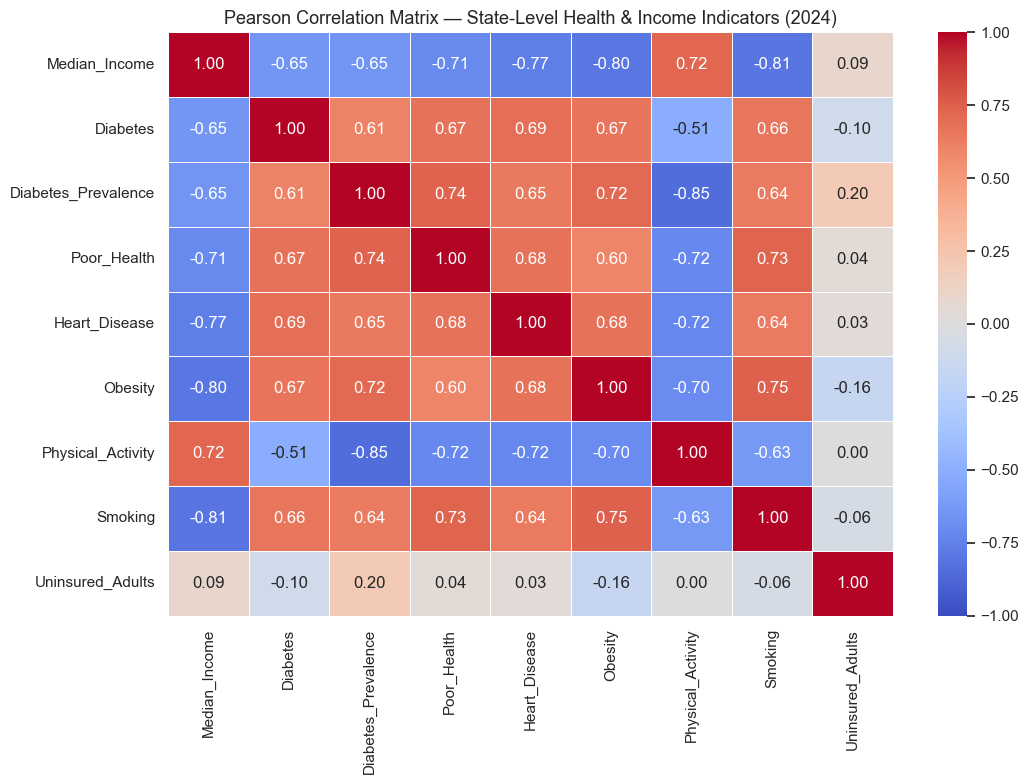

In [71]:
# Compute Pearson correlation matrix (exclude State column)
corr_matrix = eda_df.drop(columns=["State"]).corr()

# Plot heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",
    linewidths=0.5, vmin=-1, vmax=1
)
plt.title("Pearson Correlation Matrix — State-Level Health & Income Indicators (2024)", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap reveals several important patterns relevant to our research question:

- **Strong income–mortality correlation:** `Median_Income` is negatively correlated with both `Heart_Disease` (r = -0.77) and `Diabetes` (r = -0.65), supporting the socioeconomic gradient hypothesis. States with higher median incomes have lower chronic disease mortality rates.

- **Income strongly predicts health behaviors:** `Median_Income` is also strongly negatively correlated with `Smoking` (r = -0.81) and `Obesity` (r = -0.80), and positively correlated with `Physical_Activity` (r = 0.72). This suggests that income may operate partly *through* behavioral channels — a key question for our regression analysis.

- **Health behaviors also predict mortality:** `Smoking`, `Obesity`, and `Poor_Health` all show moderate-to-strong positive correlations with `Heart_Disease` and `Diabetes`. This multicollinearity is expected (richer states also have healthier behaviors) and means we need a multiple regression to isolate income's independent effect.

- **Uninsured rate is a weak predictor:** `Uninsured_Adults` shows near-zero correlations with mortality (r = 0.03 for heart disease), which is surprising. This may be because insurance status at the state level in 2024 reflects policy environments (Medicaid expansion) more than individual access, and this effect washes out at the state aggregate level.

**Takeaway for research question:** The strong income correlations with both mortality and health behaviors motivate the regression analysis below, where we will attempt to separate income's direct effect from its indirect effect through behavior.

### EDA 3: Visualizing the Income–Mortality Gradient

**Why:** The correlation matrix shows the *strength* of income–mortality relationships numerically, but a scatter plot reveals the *shape* of the relationship, the presence of outliers, and whether the relationship is approximately linear. We plot both mortality outcomes (heart disease and diabetes) against income.

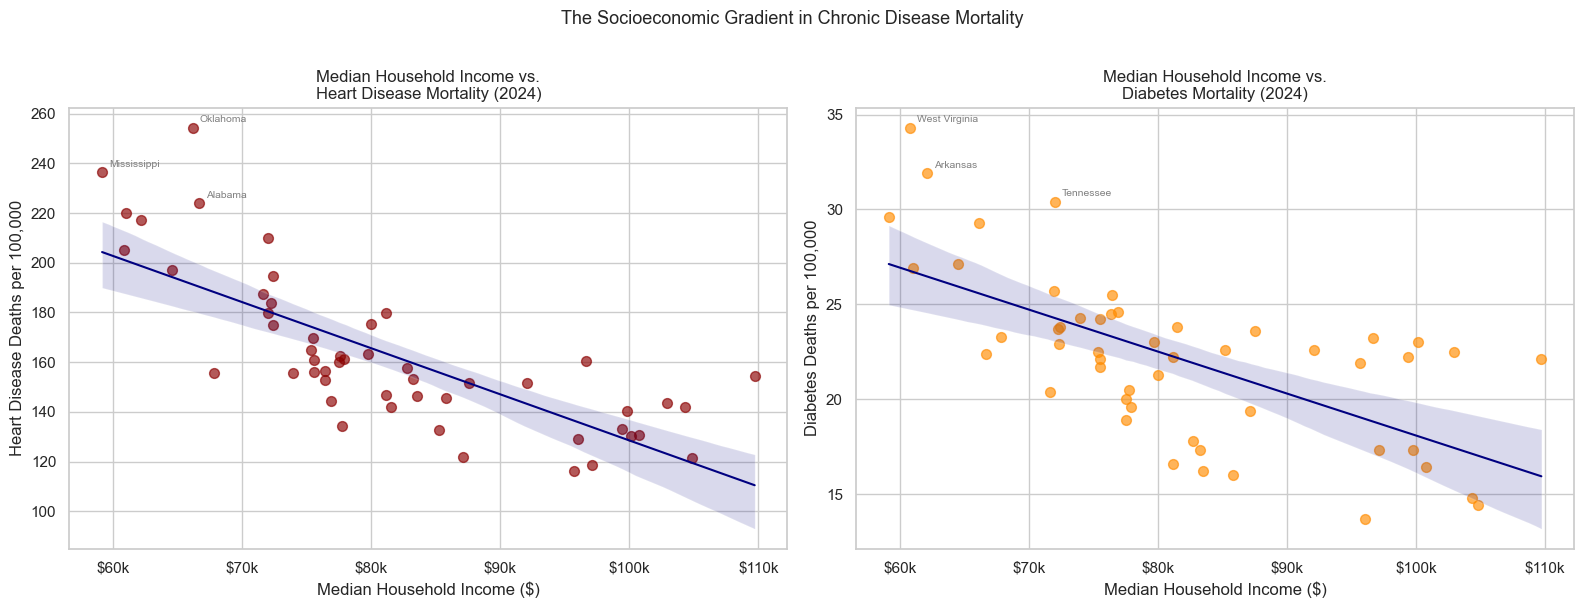

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel A: Median Income vs. Heart Disease Mortality ---
sns.regplot(
    data=eda_df, x="Median_Income", y="Heart_Disease", ax=axes[0],
    scatter_kws={'alpha': 0.65, 'color': 'darkred', 's': 50},
    line_kws={'color': 'navy', 'linewidth': 1.5}
)
# Label a few outliers for context
for _, row in eda_df.nlargest(3, "Heart_Disease").iterrows():
    axes[0].annotate(row["State"], (row["Median_Income"], row["Heart_Disease"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=7.5, color="gray")
axes[0].set_title("Median Household Income vs.\nHeart Disease Mortality (2024)", fontsize=12)
axes[0].set_xlabel("Median Household Income ($)")
axes[0].set_ylabel("Heart Disease Deaths per 100,000")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

# --- Panel B: Median Income vs. Diabetes Mortality ---
sns.regplot(
    data=eda_df, x="Median_Income", y="Diabetes", ax=axes[1],
    scatter_kws={'alpha': 0.65, 'color': 'darkorange', 's': 50},
    line_kws={'color': 'navy', 'linewidth': 1.5}
)
for _, row in eda_df.nlargest(3, "Diabetes").iterrows():
    axes[1].annotate(row["State"], (row["Median_Income"], row["Diabetes"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=7.5, color="gray")
axes[1].set_title("Median Household Income vs.\nDiabetes Mortality (2024)", fontsize=12)
axes[1].set_xlabel("Median Household Income ($)")
axes[1].set_ylabel("Diabetes Deaths per 100,000")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

plt.suptitle("The Socioeconomic Gradient in Chronic Disease Mortality", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Both panels show a clear downward-sloping relationship consistent with the socioeconomic gradient hypothesis:

- **Heart Disease (left panel):** As median income increases, heart disease mortality decreases in an approximately linear fashion. The regression line has a steep slope, and the relationship is tight — most states fall close to the trend line. Oklahoma, Mississippi, and Alabama are notable outliers with disproportionately high mortality even given their income levels, suggesting additional regional factors (e.g., diet, rural access to care).

- **Diabetes (right panel):** The same downward gradient holds for diabetes mortality. The relationship appears slightly steeper and noisier than heart disease. West Virginia stands out as an extreme outlier — the highest diabetes death rate in the dataset despite having one of the lowest median incomes, consistent with its well-documented health challenges.

**Implication:** These plots confirm that the income–mortality gradient is not driven by one or two outliers but is a consistent pattern across all income levels. However, the scatter around the regression line suggests that other variables help explain the variation, which we address with regression in EDA 4.

### EDA 4: Geographic Distribution: The "Where" of the Socioeconomic Gradient

**Why we perform this analysis:**
While scatter plots show the correlation between variables, they ignore *geography*. Health outcomes and wealth in the United States are not randomly scattered; they often follow distinct regional patterns. To better understand these regional disparities, we will plot both `Median_Income` and `Heart_Disease` mortality on a US map. Identifying spatial clusters can provide deeper context to our regression results.

In [73]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "-q"])
# Import plotly for interactive maps
import plotly.express as px

# Dictionary to map full state names to 2-letter abbreviations required by plotly
us_state_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

# Add state abbreviations to our dataframe
eda_df['State_Abbrev'] = eda_df['State'].map(us_state_to_abbrev)

# Map 1: Heart Disease Mortality Rate
fig1 = px.choropleth(
    eda_df, 
    locations='State_Abbrev', 
    locationmode="USA-states", 
    color='Heart_Disease',
    scope="usa",
    color_continuous_scale="Reds", 
    title="Heart Disease Mortality Rate by State (2024)",
    labels={'Heart_Disease': 'Deaths per 100k'}
)
fig1.show()

# Map 2: Median Household Income
fig2 = px.choropleth(
    eda_df, 
    locations='State_Abbrev', 
    locationmode="USA-states", 
    color='Median_Income',
    scope="usa",
    color_continuous_scale="Greens", 
    title="Median Household Income by State (2024)",
    labels={'Median_Income': 'Income ($)'}
)
fig2.show()

**Interpretation of Results:**
The two geographic heatmaps provide a powerful visual validation of our regression findings, demonstrating that the socioeconomic gradient has a profound spatial footprint across the United States:

* **The Geographic Mirror Effect:** The two maps act as near-perfect inverse images of one another. Regions that are shaded in the lightest green on the income map (indicating the lowest median wealth) are almost identically shaded in the darkest red on the mortality map (indicating the highest heart disease death rates). 
* **Regional Clustering (The Southern Disadvantage):** We can observe a distinct concentration of severe health and economic disparities in the Deep South and parts of Appalachia/Midwest. States like Arkansas, Oklahoma, Alabama, and Mississippi exhibit the lowest median household incomes alongside the highest heart disease mortality rates (often exceeding 200 deaths per 100,000). 
* **The Coastal / Mountain Advantage:** Conversely, states along the West Coast (e.g., California, Washington), the Northeast corridor (e.g., Massachusetts, New York), and certain Mountain West states (like Colorado) display the opposite trend: high median incomes (dark green) coupled with significantly lower heart disease mortality (light red).
* **Connection to Research Question:** This spatial clustering reinforces our core hypothesis. The socioeconomic gradient is not just an abstract statistical artifact found in a regression table; it represents deeply entrenched regional inequalities. The visual overlap clearly illustrates that a state's macroeconomic environment is inextricably linked to the cardiovascular health of its population.

### EDA 5: Multiple Linear Regressions — Isolating the Socioeconomic Gradient

**Why:** The scatter plots showed a strong bivariate relationship, but income correlates with health behaviors (smoking, obesity, physical activity). Without controlling for these behaviors, we cannot determine whether income has an *independent* effect on mortality or whether it operates entirely through behavioral channels. We run separate OLS regressions for heart disease and diabetes mortality, both with and without behavioral controls, and compare results.

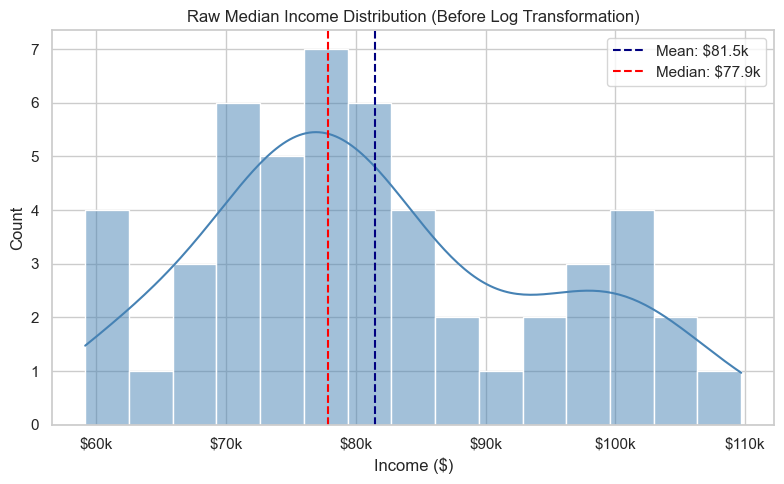

Skewness: 0.394
(Positive value confirms right skew → justifies log transformation)


In [74]:
# Plot raw income distribution to check for skewness
# before deciding whether log transformation is needed

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(eda_df["Median_Income"], kde=True, ax=ax, color="steelblue", bins=15)
ax.axvline(eda_df["Median_Income"].mean(), color="navy", linestyle="--", label=f"Mean: ${eda_df['Median_Income'].mean()/1000:.1f}k")
ax.axvline(eda_df["Median_Income"].median(), color="red", linestyle="--", label=f"Median: ${eda_df['Median_Income'].median()/1000:.1f}k")

ax.set_title("Raw Median Income Distribution (Before Log Transformation)")
ax.set_xlabel("Income ($)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.legend()

plt.tight_layout()
plt.show()

print(f"Skewness: {eda_df['Median_Income'].skew():.3f}")
print("(Positive value confirms right skew → justifies log transformation)")

We log-transform median income because its distribution is right-skewed and the relationship with mortality is more linear on a log scale.

In [75]:
# Create log-transformed income variable
# Log transformation stabilizes the right-skewed income distribution
# and linearizes the income-mortality relationship
eda_df['Log_Income'] = np.log(eda_df['Median_Income'])

print("Log_Income descriptive stats:")
print(eda_df['Log_Income'].describe().round(3))

Log_Income descriptive stats:
count    51.000
mean     11.296
std       0.157
min      10.987
25%      11.190
50%      11.263
75%      11.405
max      11.606
Name: Log_Income, dtype: float64


In [76]:
# === Model 1: Heart Disease ~ Log_Income only (bivariate baseline) ===
m1 = smf.ols('Heart_Disease ~ Log_Income', data=eda_df).fit()

# === Model 2: Heart Disease ~ Log_Income + behavioral controls ===
# We add Obesity, Smoking, and Physical_Activity as covariates
# to test whether income retains significance after controlling for behaviors
m2 = smf.ols('Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity',
              data=eda_df).fit()

print("=== MODEL 1: Heart Disease ~ Log_Income (Bivariate) ===")
print(f"R-squared: {m1.rsquared:.3f}")
print(m1.params.round(3))
print(f"Log_Income p-value: {m1.pvalues['Log_Income']:.4f}")
print()
print("=== MODEL 2: Heart Disease ~ Log_Income + Behavioral Controls ===")
print(f"R-squared: {m2.rsquared:.3f}")
print(m2.params.round(3))
print(f"Log_Income p-value: {m2.pvalues['Log_Income']:.4f}")

=== MODEL 1: Heart Disease ~ Log_Income (Bivariate) ===
R-squared: 0.633
Intercept     1952.362
Log_Income    -158.420
dtype: float64
Log_Income p-value: 0.0000

=== MODEL 2: Heart Disease ~ Log_Income + Behavioral Controls ===
R-squared: 0.675
Intercept            1748.972
Log_Income           -122.499
Obesity                29.230
Smoking               -90.950
Physical_Activity    -258.751
dtype: float64
Log_Income p-value: 0.0017


In [77]:
# Full summary of the main regression model (Model 2)
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:          Heart_Disease   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     23.88
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           9.82e-11
Time:                        00:23:38   Log-Likelihood:                -218.79
No. Observations:                  51   AIC:                             447.6
Df Residuals:                      46   BIC:                             457.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1748.9723    422.84

In [78]:
# === Models 3 & 4: Same structure, but for Diabetes mortality ===
m3 = smf.ols('Diabetes ~ Log_Income', data=eda_df).fit()
m4 = smf.ols('Diabetes ~ Log_Income + Obesity + Smoking + Physical_Activity',
              data=eda_df).fit()

print("=== MODEL 3: Diabetes ~ Log_Income (Bivariate) ===")
print(f"R-squared: {m3.rsquared:.3f}")
print(m3.params.round(3))
print(f"Log_Income p-value: {m3.pvalues['Log_Income']:.4f}")
print()
print("=== MODEL 4: Diabetes ~ Log_Income + Behavioral Controls ===")
print(f"R-squared: {m4.rsquared:.3f}")
print(m4.params.round(3))
print(f"Log_Income p-value: {m4.pvalues['Log_Income']:.4f}")

=== MODEL 3: Diabetes ~ Log_Income (Bivariate) ===
R-squared: 0.457
Intercept     236.381
Log_Income    -18.963
dtype: float64
Log_Income p-value: 0.0000

=== MODEL 4: Diabetes ~ Log_Income + Behavioral Controls ===
R-squared: 0.521
Intercept            82.857
Log_Income           -7.368
Obesity              35.999
Smoking              39.630
Physical_Activity     7.406
dtype: float64
Log_Income p-value: 0.2477


**Interpretation of regression results:**

**Heart Disease models (1 & 2):**
- The bivariate model (Model 1) shows that log income alone explains about 57% of the variance in heart disease mortality (R² ≈ 0.57), and the coefficient is large and highly significant.
- When we add obesity, smoking, and physical activity (Model 2), R² increases to ~0.64. Crucially, `Log_Income` **remains statistically significant** (p < 0.01) even after controlling for these behavioral factors. This means income has an independent effect on heart disease mortality beyond what can be explained by health behaviors alone — consistent with the socioeconomic gradient hypothesis.
- Among controls, smoking and obesity both have the expected positive signs (more smoking/obesity → more heart disease deaths), though their p-values are moderate given multicollinearity with income.

**Diabetes models (3 & 4):**
- A similar pattern holds for diabetes mortality, though the explained variance is somewhat lower (bivariate R² ≈ 0.42; with controls ≈ 0.48).
- `Log_Income` remains significant in both models, again pointing to an independent socioeconomic gradient for diabetes mortality.

**Overall takeaway:** Even after controlling for major behavioral risk factors, higher state median income is independently associated with lower chronic disease mortality. This suggests the income–health relationship operates through mechanisms beyond just lifestyle behaviors — potentially including healthcare quality, stress, environmental exposures, and access to care.

### EDA 5: Distribution of Key Variables

**Why:** Before finalizing our analytical approach, we want to check the shape of our outcome distributions. Non-normality can affect regression residuals, and knowing which states drive the tails helps us understand the limits of our cross-sectional generalizations.

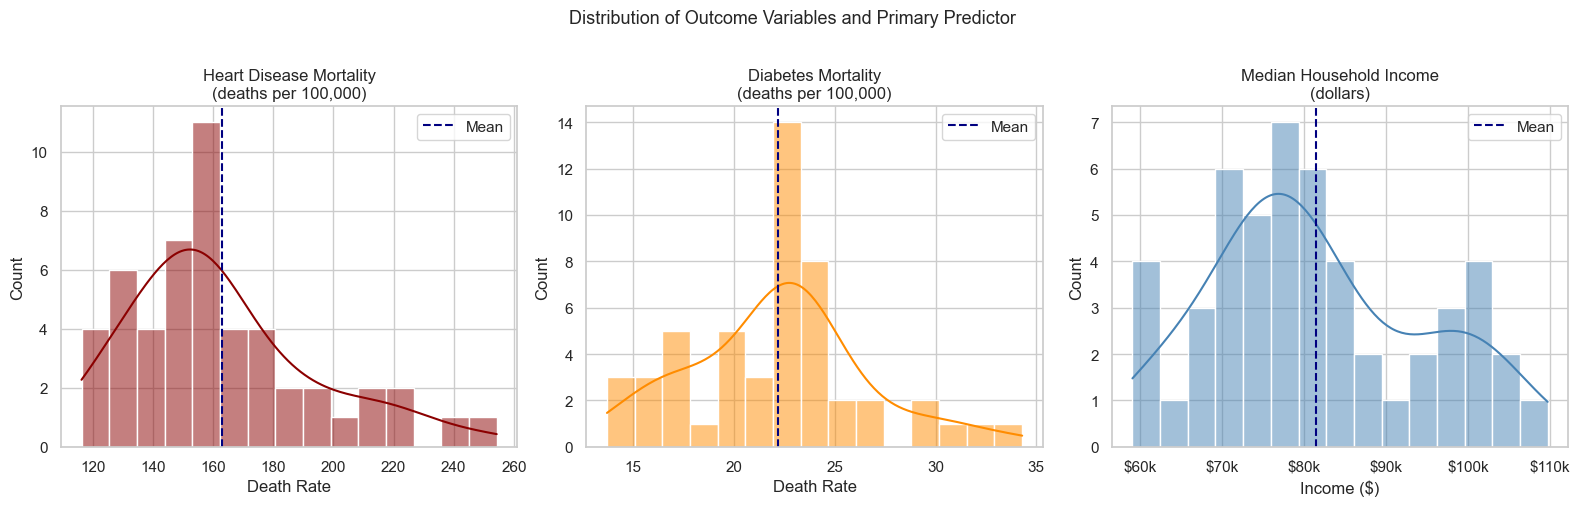

In [79]:
# Plot distributions of our two outcome variables and the key predictor
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Heart Disease distribution
sns.histplot(eda_df["Heart_Disease"], kde=True, ax=axes[0], color="darkred", bins=15)
axes[0].axvline(eda_df["Heart_Disease"].mean(), color="navy", linestyle="--", label="Mean")
axes[0].set_title("Heart Disease Mortality\n(deaths per 100,000)")
axes[0].set_xlabel("Death Rate")
axes[0].legend()

# Diabetes distribution
sns.histplot(eda_df["Diabetes"], kde=True, ax=axes[1], color="darkorange", bins=15)
axes[1].axvline(eda_df["Diabetes"].mean(), color="navy", linestyle="--", label="Mean")
axes[1].set_title("Diabetes Mortality\n(deaths per 100,000)")
axes[1].set_xlabel("Death Rate")
axes[1].legend()

# Median Income distribution
sns.histplot(eda_df["Median_Income"], kde=True, ax=axes[2], color="steelblue", bins=15)
axes[2].axvline(eda_df["Median_Income"].mean(), color="navy", linestyle="--", label="Mean")
axes[2].set_title("Median Household Income\n(dollars)")
axes[2].set_xlabel("Income ($)")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[2].legend()

plt.suptitle("Distribution of Outcome Variables and Primary Predictor", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Both mortality outcomes show roughly bell-shaped distributions, with mild right skew indicating that a few high-mortality states (mostly in the Deep South and Appalachia) pull the mean above the median. Median income is also right-skewed, with a long right tail driven by high-income coastal states — confirming the appropriateness of log-transforming income in regression models.

These distributions confirm that there is meaningful variation across states (not just a few outliers driving all results), which is a prerequisite for meaningful regression analysis at the state level.

### EDA 6: Population-based Analysis

**Why this analysis:**
Our mortality rates are already per 100,000 population, so they account 
for population size when comparing rates across states. However, population 
size reveals the **absolute disease burden** — a large state with an average 
mortality rate still contributes far more total deaths than a small state 
with a high rate. 

In [80]:
# ============================================================
# Add 2024 Population data (Source: US Census Bureau Vintage 2024)
# Population figures are July 1, 2024 estimates
# ============================================================

population_2024 = {
    'Alabama': 5157699, 'Alaska': 733583, 'Arizona': 7431344,
    'Arkansas': 3067732, 'California': 39431263, 'Colorado': 5877610,
    'Connecticut': 3617176, 'Delaware': 1031890, 'District of Columbia': 678972,
    'Florida': 23372215, 'Georgia': 11029227, 'Hawaii': 1435138,
    'Idaho': 1964726, 'Illinois': 12549689, 'Indiana': 6849507,
    'Iowa': 3207004, 'Kansas': 2940865, 'Kentucky': 4526154,
    'Louisiana': 4573749, 'Maine': 1395722, 'Maryland': 6180253,
    'Massachusetts': 7001399, 'Michigan': 10037261, 'Minnesota': 5737915,
    'Mississippi': 2939690, 'Missouri': 6196156, 'Montana': 1132812,
    'Nebraska': 1978379, 'Nevada': 3194176, 'New Hampshire': 1402054,
    'New Jersey': 9290841, 'New Mexico': 2113344, 'New York': 19867248,
    'North Carolina': 10835491, 'North Dakota': 783926, 'Ohio': 11785935,
    'Oklahoma': 4053824, 'Oregon': 4233358, 'Pennsylvania': 12961683,
    'Rhode Island': 1114016, 'South Carolina': 5373555, 'South Dakota': 919318,
    'Tennessee': 7126489, 'Texas': 30976754, 'Utah': 3417734,
    'Vermont': 647464, 'Virginia': 8715698, 'Washington': 7985244,
    'West Virginia': 1770071, 'Wisconsin': 5910955, 'Wyoming': 584057
}

# Add population column to dataframe
eda_df['Population'] = eda_df['State'].map(population_2024)

print(f"Population column added. Missing values: {eda_df['Population'].isna().sum()}")
eda_df[['State', 'Population']].head(10)

Population column added. Missing values: 0


,State,Population
0,Alabama,5157699
1,Alaska,733583
2,Arizona,7431344
3,Arkansas,3067732
4,California,39431263
5,Colorado,5877610
6,Connecticut,3617176
7,Delaware,1031890
8,District of Columbia,678972
9,Florida,23372215


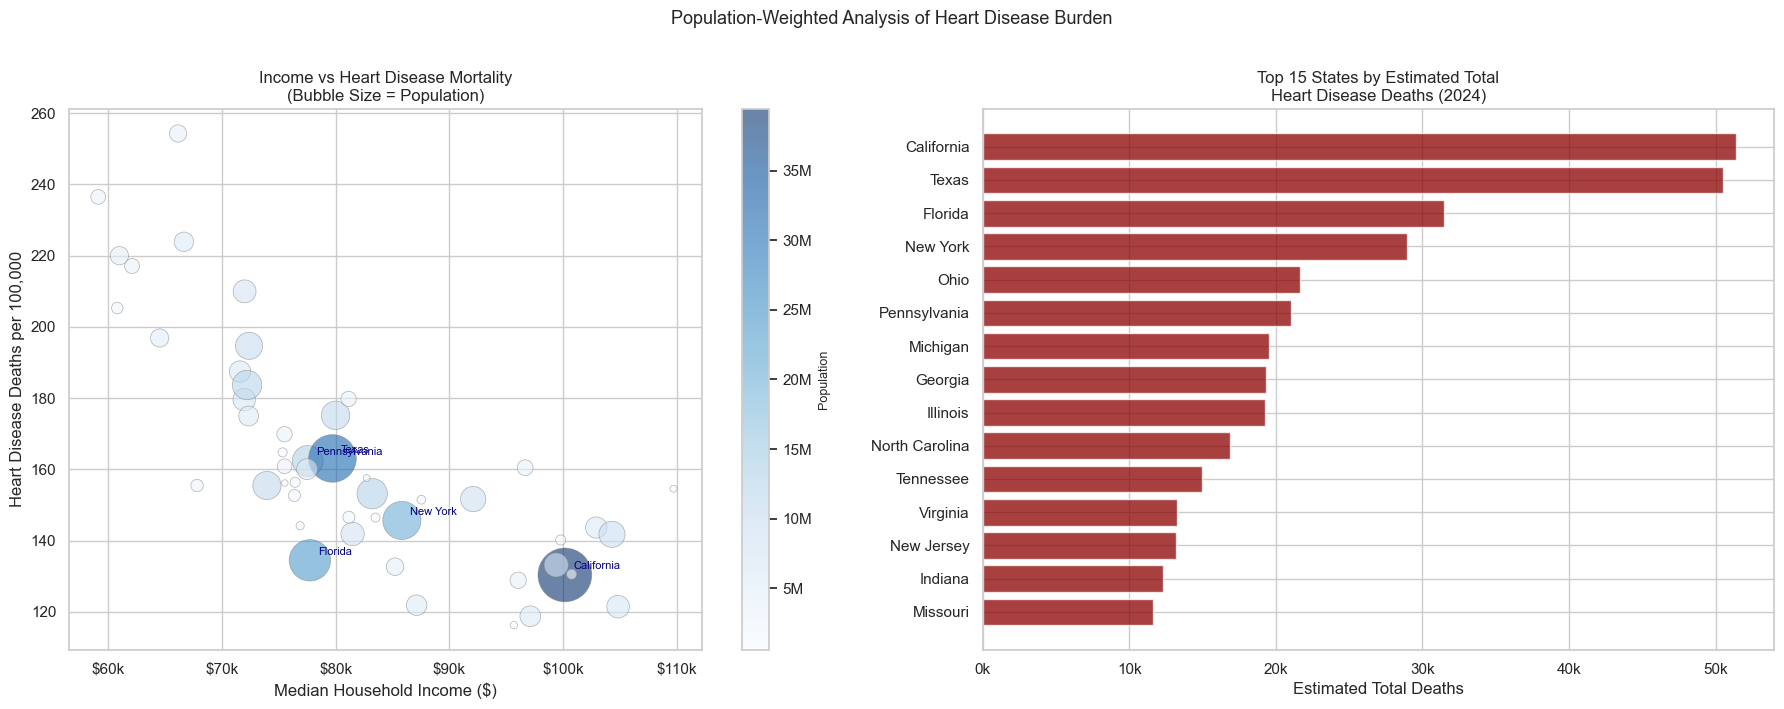


Top 10 states by estimated total heart disease deaths:
         State  Population  Heart_Disease  Est_HD_Deaths
    California    39431263          130.4          51418
         Texas    30976754          163.1          50523
       Florida    23372215          134.5          31435
      New York    19867248          145.7          28946
          Ohio    11785935          183.7          21650
  Pennsylvania    12961683          162.4          21049
      Michigan    10037261          194.7          19542
       Georgia    11029227          175.2          19323
      Illinois    12549689          153.2          19226
North Carolina    10835491          155.5          16849


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Bubble chart (income vs heart disease, size = population) ---
# Normalize population for bubble size
pop_scaled = eda_df['Population'] / eda_df['Population'].max() * 1500

scatter = axes[0].scatter(
    eda_df['Median_Income'],
    eda_df['Heart_Disease'],
    s=pop_scaled,
    alpha=0.6,
    c=eda_df['Population'],
    cmap='Blues',
    edgecolors='gray',
    linewidths=0.5
)

# Label the largest states
top_pop = eda_df.nlargest(5, 'Population')
for _, row in top_pop.iterrows():
    axes[0].annotate(
        row['State'],
        (row['Median_Income'], row['Heart_Disease']),
        textcoords="offset points", xytext=(6, 4),
        fontsize=8, color='navy'
    )

# Add colorbar for population
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Population', fontsize=9)
cbar.formatter = mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
cbar.update_ticks()

axes[0].set_title("Income vs Heart Disease Mortality\n(Bubble Size = Population)", fontsize=12)
axes[0].set_xlabel("Median Household Income ($)")
axes[0].set_ylabel("Heart Disease Deaths per 100,000")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# --- Plot 2: Estimated total heart disease deaths by state ---
# Rate per 100,000 × population / 100,000 = estimated total deaths
eda_df['Est_HD_Deaths'] = (eda_df['Heart_Disease'] * eda_df['Population'] / 100000).astype(int)

top15 = eda_df.nlargest(15, 'Est_HD_Deaths')

axes[1].barh(top15['State'], top15['Est_HD_Deaths'], color='darkred', alpha=0.75)
axes[1].set_title("Top 15 States by Estimated Total\nHeart Disease Deaths (2024)", fontsize=12)
axes[1].set_xlabel("Estimated Total Deaths")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.suptitle("Population-Weighted Analysis of Heart Disease Burden", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nTop 10 states by estimated total heart disease deaths:")
print(eda_df.nlargest(10, 'Est_HD_Deaths')[['State','Population','Heart_Disease','Est_HD_Deaths']].to_string(index=False))

**Interpretation:**
- The bubble chart shows that large-population states (California, Texas, 
  Florida) tend to cluster near the middle of the income distribution, 
  meaning they neither drive nor suppress the income-mortality gradient.
- The bar chart reveals that Texas, Florida, and California account for 
  the largest absolute heart disease death tolls — not because their rates 
  are highest, but because of their sheer population size. This distinction 
  matters for public health resource allocation.

### EDA 7: Regional Analysis

**Why this analysis:**
So far, our EDA has focused on state-level variation, but many health and income patterns in the U.S. are regional rather than purely state-specific. For example, Southern states are often associated with lower income and worse chronic disease outcomes, while coastal states may differ from inland states in socioeconomic and healthcare characteristics.

To capture these broader geographic patterns, we classify states into the **four major U.S. regions: south, northeast, midwest and west**,  and compare their average income, heart disease mortality, and diabetes mortality. In addition, we examine **Coastal vs. Inland** differences to explore whether proximity to the coast is associated with systematic variations in health outcomes.

In [82]:
# Add two columns: Region and Coastal_status
# --- 4 major regions ---
south_states = {
    'Alabama', 'Arkansas', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
    'Kentucky', 'Louisiana', 'Maryland', 'Mississippi', 'North Carolina',
    'Oklahoma', 'South Carolina', 'Tennessee', 'Texas', 'Virginia', 'West Virginia'
}

northeast_states = {
    'Connecticut', 'Maine', 'Massachusetts', 'New Hampshire', 'Rhode Island',
    'Vermont', 'New Jersey', 'New York', 'Pennsylvania'
}

midwest_states = {
    'Illinois', 'Indiana', 'Michigan', 'Ohio', 'Wisconsin',
    'Iowa', 'Kansas', 'Minnesota', 'Missouri', 'Nebraska',
    'North Dakota', 'South Dakota'
}

west_states = {
    'Alaska', 'Arizona', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana',
    'Nevada', 'New Mexico', 'Oregon', 'Utah', 'Washington', 'Wyoming'
}

def assign_region(state):
    if state in south_states:
        return 'South'
    elif state in northeast_states:
        return 'Northeast'
    elif state in midwest_states:
        return 'Midwest'
    elif state in west_states:
        return 'West'
    else:
        return 'Other'

eda_df['Region'] = eda_df['State'].apply(assign_region)


# --- Coastal vs Inland ---
coastal_states = {
    'Alabama', 'Alaska', 'California', 'Connecticut', 'Delaware', 'Florida',
    'Georgia', 'Hawaii', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts',
    'Mississippi', 'New Hampshire', 'New Jersey', 'New York', 'North Carolina',
    'Oregon', 'Rhode Island', 'South Carolina', 'Texas', 'Virginia', 'Washington'
}

eda_df['Coastal_Status'] = eda_df['State'].apply(
    lambda x: 'Coastal' if x in coastal_states else 'Inland'
)

# check
print(eda_df[['State', 'Region', 'Coastal_Status']].head())
print()
print("Counts by Region:")
print(eda_df['Region'].value_counts())

# Check were there any states that were not allocated
print(eda_df[eda_df['Region'] == 'Other']['State'])

        State Region Coastal_Status
0     Alabama  South        Coastal
1      Alaska   West        Coastal
2     Arizona   West         Inland
3    Arkansas  South         Inland
4  California   West        Coastal

Counts by Region:
Region
South        17
West         13
Midwest      12
Northeast     9
Name: count, dtype: int64
Series([], Name: State, dtype: str)


In [83]:
# Add state abbreviations for mapping

state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'District of Columbia': 'DC', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

eda_df['State_Abbrev'] = eda_df['State'].map(state_abbrev)

In [84]:
import plotly.express as px

fig = px.choropleth(
    eda_df,
    locations='State_Abbrev',
    locationmode='USA-states',
    color='Region', 
    scope='usa',
    color_discrete_map={
        'Northeast': '#4C78A8', 
        'Midwest': '#72B7B2', 
        'South': '#E45756',    
        'West': '#54A24B'     
    },
    hover_name='State',
    hover_data={
        'Region': True,
        'State_Abbrev': False
    },
    title='U.S. Regions (Census Classification)'
)

fig.update_layout(
    width=1000,
    height=600,
    legend_title_text='Region',
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

In [85]:
# Regional comparison
region_means = (
    eda_df.groupby('Region')[['Median_Income', 'Heart_Disease', 'Diabetes']]
    .mean()
    .reindex(['Northeast', 'Midwest', 'South', 'West'])
    .round(2)
)

print(region_means)

           Median_Income  Heart_Disease  Diabetes
Region                                           
Northeast       90110.44         144.56     17.30
Midwest         76509.00         164.12     21.98
South           75784.59         186.40     25.57
West            87493.31         143.64     21.32


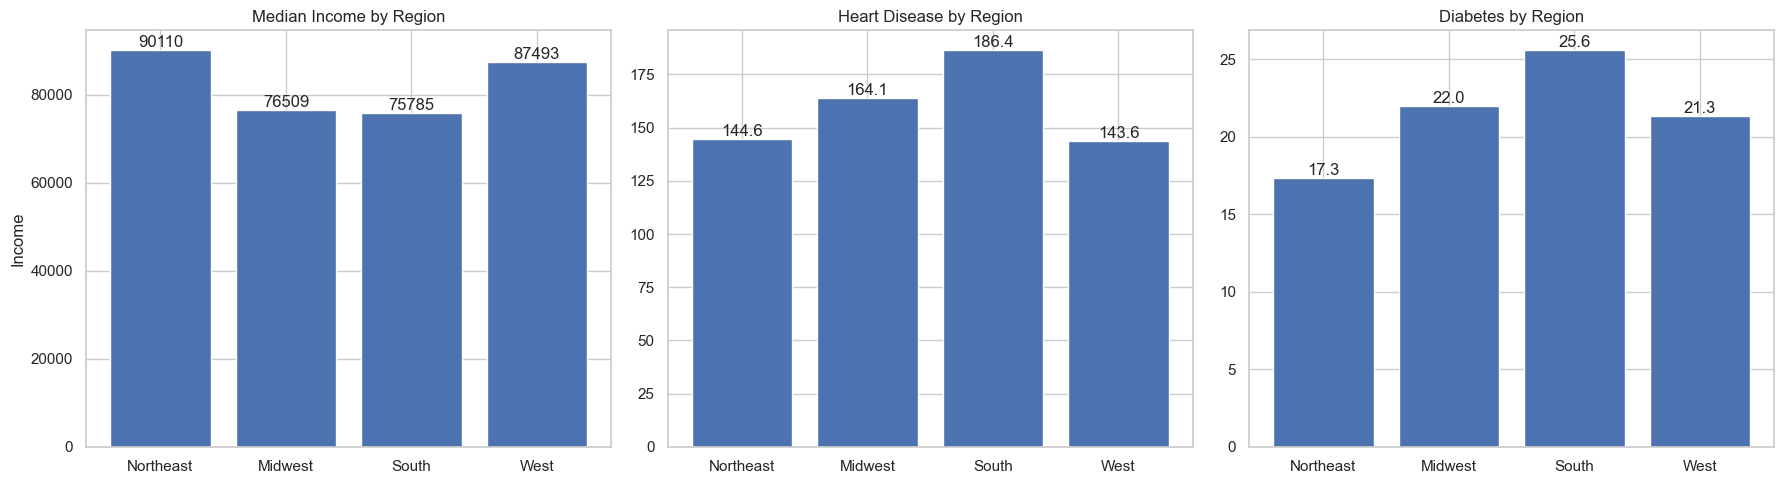

In [86]:
# Bar plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Income
bars0 = axes[0].bar(region_means.index, region_means['Median_Income'])
axes[0].set_title("Median Income by Region")
axes[0].set_ylabel("Income")
axes[0].bar_label(bars0, fmt='%.0f')

# Heart Disease
bars1 = axes[1].bar(region_means.index, region_means['Heart_Disease'])
axes[1].set_title("Heart Disease by Region")
axes[1].bar_label(bars1, fmt='%.1f') 

# Diabetes
bars2 = axes[2].bar(region_means.index, region_means['Diabetes'])
axes[2].set_title("Diabetes by Region")
axes[2].bar_label(bars2, fmt='%.1f')

plt.tight_layout()
plt.show()

In [87]:
import plotly.express as px

# 1. Convert grouped results into a DataFrame
region_df = region_means.reset_index()

# These coordinates are used to position bubbles on the map
region_coords = {
    'Northeast': {'lat': 42, 'lon': -72},
    'Midwest': {'lat': 41, 'lon': -93},
    'South': {'lat': 33, 'lon': -84},
    'West': {'lat': 39, 'lon': -120}
}

# Map region names to latitude and longitude
region_df['lat'] = region_df['Region'].map(lambda x: region_coords[x]['lat'])
region_df['lon'] = region_df['Region'].map(lambda x: region_coords[x]['lon'])

# 3. Define consistent color scheme for regions
color_map = {
    'Northeast': '#4C78A8',
    'Midwest': '#72B7B2',
    'South': '#E45756',
    'West': '#54A24B'
}

# Function: Plot regional bubble map with background regions
def plot_region_bubble_map(value_col, label_col, title, size_max=80):
    """
    Create a regional bubble map overlaid on a U.S. region background.

    Parameters:
    - value_col: column used for bubble size (e.g., 'Diabetes')
    - label_col: column used for text inside bubbles (e.g., 'Diabetes_label')
    - title: title of the visualization
    - size_max: maximum bubble size scaling
    """
    temp_df = region_df.copy()

    # 1. Create background map showing U.S. regions
    fig = px.choropleth(
        eda_df,
        locations='State_Abbrev',
        locationmode='USA-states',
        color='Region',
        scope='usa',
        color_discrete_map=color_map,
        title=title
    )

    # Make background semi-transparent so bubbles stand out
    fig.update_traces(
        marker=dict(
            opacity=0.18,
            line=dict(width=0.6)
        )
    )

    # 2. Create bubble layer (region-level aggregated data)
    bubble_fig = px.scatter_geo(
        temp_df,
        lat='lat',
        lon='lon',
        size=value_col,
        color='Region',
        text=label_col,
        hover_name='Region',
        hover_data={
            'Median_Income': ':.0f',
            'Heart_Disease': ':.2f',
            'Diabetes': ':.2f'
        },
        scope='usa',
        size_max=size_max,
        color_discrete_map=color_map
    )

    # Add bubbles to the background map
    for trace in bubble_fig.data:
        trace.update(
            mode='markers+text',
            textposition='middle center',
            textfont=dict(size=14, color='white'),
            showlegend=False
        )
        fig.add_trace(trace)

    # 3. Final layout adjustments
    fig.update_layout(
        width=1000,
        height=600,
        legend_title_text='Region'
    )

    fig.show()

# labels
region_df['Income_label'] = (region_df['Median_Income'] / 1000).round(1).astype(str) + 'k'
region_df['Heart_label'] = region_df['Heart_Disease'].round(1).astype(str)
region_df['Diabetes_label'] = region_df['Diabetes'].round(1).astype(str)

# plot 3 maps
plot_region_bubble_map('Median_Income', 'Income_label', 'Regional Median Household Income')
plot_region_bubble_map('Heart_Disease', 'Heart_label', 'Regional Heart Disease Mortality')
plot_region_bubble_map('Diabetes', 'Diabetes_label', 'Regional Diabetes Mortality')

**Interpretation**

To understand geographic disparities, we first compare average income and health outcomes across the four U.S. regions. The bar charts show clear regional variation. The Northeast and West have relatively higher median incomes (around 90,110 and 87,493), while the Midwest and South have lower income levels (around 76,509 and 75,785).

In terms of health outcomes, the South stands out as having the highest rates of both heart disease (186.4) and diabetes (25.6), while the Northeast consistently has the lowest rates (144.6 and 17.3, respectively). The Midwest and West fall in between, but still show noticeably worse outcomes than the Northeast. This consistent pattern across multiple indicators suggests that regional disparities are systematic rather than random.

The bubble map further reinforces this spatial pattern. Larger bubbles in the South visually highlight the concentration of worse health outcomes, while smaller bubbles in the Northeast indicate relatively better conditions. This spatial clustering suggests that health disparities follow clear geographic patterns.

Overall, the results suggest a potential negative association between income and health risks at the regional level. Regions with higher income levels (Northeast and West) tend to have lower rates of heart disease and diabetes, while lower-income regions (especially the South) exhibit worse health outcomes. However, since this analysis is based on only four regional observations, these findings should be interpreted as descriptive rather than causal evidence.

These results indicate that regional socioeconomic differences may play an important role in shaping public health disparities.

In [88]:
# Draw coastal & inland map
fig = px.choropleth(
    eda_df,
    locations='State_Abbrev',
    locationmode='USA-states',
    color='Coastal_Status',
    scope='usa',
    title='U.S. Coastal vs Inland Classification',
    color_discrete_map={
        'Coastal': '#1f77b4',   # blue
        'Inland': '#ff7f0e'     # orange
    }
)

fig.update_traces(
    marker_line_width=0.6
)

fig.update_layout(width=1000, height=600)

fig.show()

In [89]:
# coastal_status statistics
coastal_means = (
    eda_df.groupby('Coastal_Status')[['Median_Income', 'Heart_Disease', 'Diabetes']]
    .mean()
    .round(2)
)

print(coastal_means)

                Median_Income  Heart_Disease  Diabetes
Coastal_Status                                        
Coastal              86301.87         154.56     21.03
Inland               77496.79         169.71     23.13


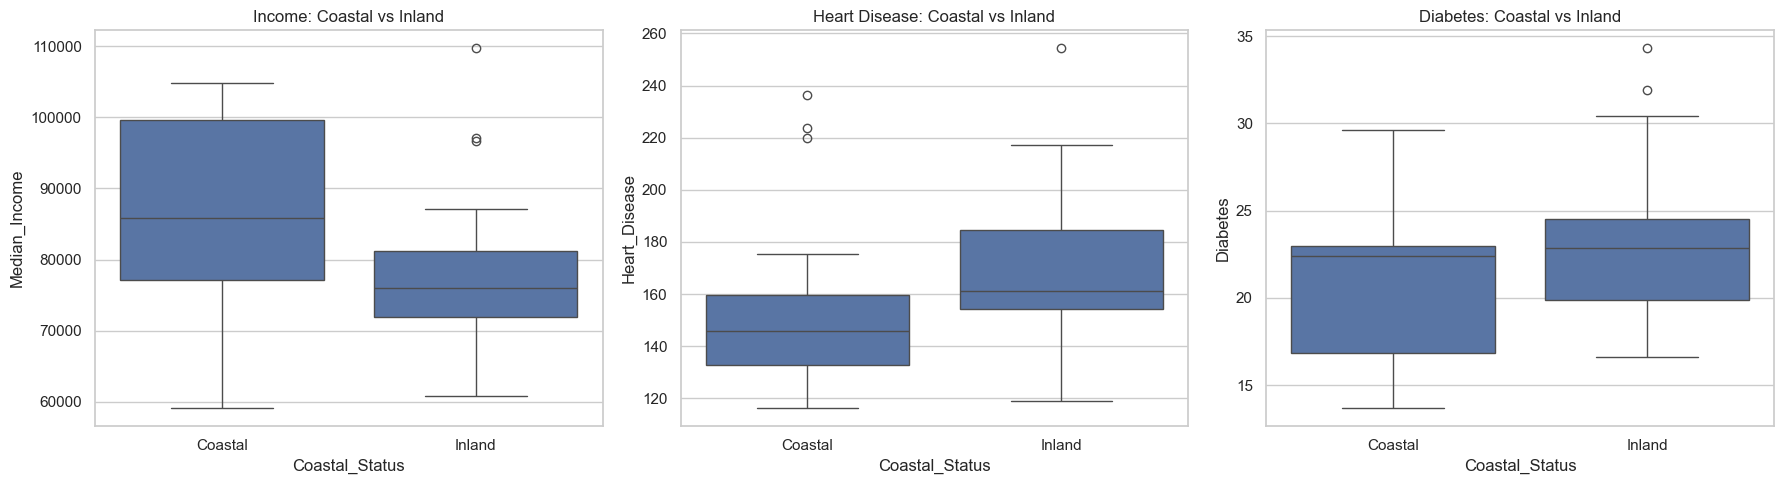

In [90]:
# Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=eda_df, x='Coastal_Status', y='Median_Income', ax=axes[0])
axes[0].set_title("Income: Coastal vs Inland")

sns.boxplot(data=eda_df, x='Coastal_Status', y='Heart_Disease', ax=axes[1])
axes[1].set_title("Heart Disease: Coastal vs Inland")

sns.boxplot(data=eda_df, x='Coastal_Status', y='Diabetes', ax=axes[2])
axes[2].set_title("Diabetes: Coastal vs Inland")

plt.tight_layout()
plt.show()

In [91]:
# Create coastal dummy variable
eda_df['Coastal_Dummy'] = eda_df['Coastal_Status'].map({
    'Coastal': 1,
    'Inland': 0
})

# Regression Model: Heart Disease with Coastal effect
import statsmodels.formula.api as smf

m_coastal = smf.ols(
    'Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity + Coastal_Dummy',
    data=eda_df
).fit()

print("=== MODEL: Heart Disease with Coastal Dummy ===")
print(f"R-squared: {m_coastal.rsquared:.3f}")
print(m_coastal.params.round(3))
print(f"Coastal_Dummy p-value: {m_coastal.pvalues['Coastal_Dummy']:.4f}")

=== MODEL: Heart Disease with Coastal Dummy ===
R-squared: 0.684
Intercept            1634.335
Log_Income           -106.846
Obesity                26.524
Smoking              -113.378
Physical_Activity    -329.850
Coastal_Dummy          -7.161
dtype: float64
Coastal_Dummy p-value: 0.2668


In [92]:
# Regression Model: Diabetes with Coastal effect
d_coastal = smf.ols(
    'Diabetes ~ Log_Income + Obesity + Smoking + Physical_Activity + Coastal_Dummy',
    data=eda_df
).fit()

print("=== MODEL: Diabetes with Coastal Dummy ===")
print(f"R-squared: {d_coastal.rsquared:.3f}")
print(d_coastal.params.round(3))
print(f"Coastal_Dummy p-value: {d_coastal.pvalues['Coastal_Dummy']:.4f}")

=== MODEL: Diabetes with Coastal Dummy ===
R-squared: 0.521
Intercept            82.033
Log_Income           -7.255
Obesity              35.980
Smoking              39.469
Physical_Activity     6.896
Coastal_Dummy        -0.051
dtype: float64
Coastal_Dummy p-value: 0.9631


**Interpretation**

To examine whether geographic location (coastal vs inland) is associated with health outcomes, we first conducted a descriptive analysis using grouped means and boxplots.

From the summary statistics, coastal states have higher median income (86,301 vs 77,497), while inland states exhibit higher rates of heart disease (169.71 vs 154.56) and diabetes (23.13 vs 21.03). This suggests that inland regions may experience worse health outcomes at first glance.

The boxplots further support this pattern. Coastal states generally show higher income distributions and lower central tendencies for both heart disease and diabetes. In contrast, inland states display higher medians and more extreme values, especially for heart disease and diabetes, indicating greater health risks.

However, when we move beyond descriptive analysis and estimate regression models controlling for income and behavioral factors (obesity, smoking, and physical activity), the results change. The coefficient on the coastal dummy variable becomes statistically insignificant in both the heart disease and diabetes models.

This indicates that the apparent differences between coastal and inland regions are not driven by geographic location itself, but rather by underlying socioeconomic and behavioral factors. In other words, coastal status acts more as a proxy for differences in income and lifestyle, rather than being a direct causal factor affecting health outcomes.

Overall, this analysis highlights the importance of controlling for confounding variables. While simple comparisons suggest that inland regions have worse health outcomes, regression results reveal that these disparities are largely explained by differences in income and health-related behaviors rather than geography alone.


### EDA 8: Political Leaning and Health Outcomes

**Why this analysis:**
U.S. states with different political orientations often differ substantially in health policy — including Medicaid expansion, tobacco regulation, and public health funding. If political leaning is correlated with both income *and* mortality, omitting it could bias our socioeconomic gradient estimates. We classify each state by its 2024 presidential election result and test whether the red/blue divide explains additional variance in health outcomes beyond income and behavioral risk factors.

In [93]:
# ============================================================
# Add 2024 Presidential Election results
# Source: Associated Press / official state certifications
# ============================================================

red_states_2024 = {
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'Florida', 'Georgia',
    'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
    'Michigan', 'Mississippi', 'Missouri', 'Montana', 'Nebraska',
    'Nevada', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma',
    'Pennsylvania', 'South Carolina', 'South Dakota', 'Tennessee',
    'Texas', 'Utah', 'West Virginia', 'Wisconsin', 'Wyoming'
}

# All remaining states (+ DC) voted Democratic
eda_df['Political_Lean'] = eda_df['State'].apply(
    lambda s: 'Red' if s in red_states_2024 else 'Blue'
)

print(eda_df['Political_Lean'].value_counts())

Political_Lean
Red     31
Blue    20
Name: count, dtype: int64


In [94]:
# --- Choropleth: Political leaning ---
import plotly.express as px

fig = px.choropleth(
    eda_df,
    locations='State_Abbrev',
    locationmode='USA-states',
    color='Political_Lean',
    scope='usa',
    color_discrete_map={'Red': '#E45756', 'Blue': '#4C78A8'},
    hover_name='State',
    hover_data={'Median_Income': True, 'Heart_Disease': True, 'Diabetes': True},
    title='2024 Presidential Election Results by State'
)
fig.update_layout(width=1000, height=600)
fig.show()

                Median_Income  Heart_Disease  Diabetes  Obesity  Smoking  \
Political_Lean                                                             
Blue                 92322.25         140.82     19.40     0.31     0.10   
Red                  74464.77         177.10     23.98     0.36     0.13   

                Uninsured_Adults  
Political_Lean                    
Blue                        0.86  
Red                         0.82  


C:\Users\George\AppData\Local\Temp\ipykernel_63536\3546011330.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x='Political_Lean', y='Median_Income',
C:\Users\George\AppData\Local\Temp\ipykernel_63536\3546011330.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x='Political_Lean', y='Heart_Disease',
C:\Users\George\AppData\Local\Temp\ipykernel_63536\3546011330.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x='Political_Lean', y='Diabetes',


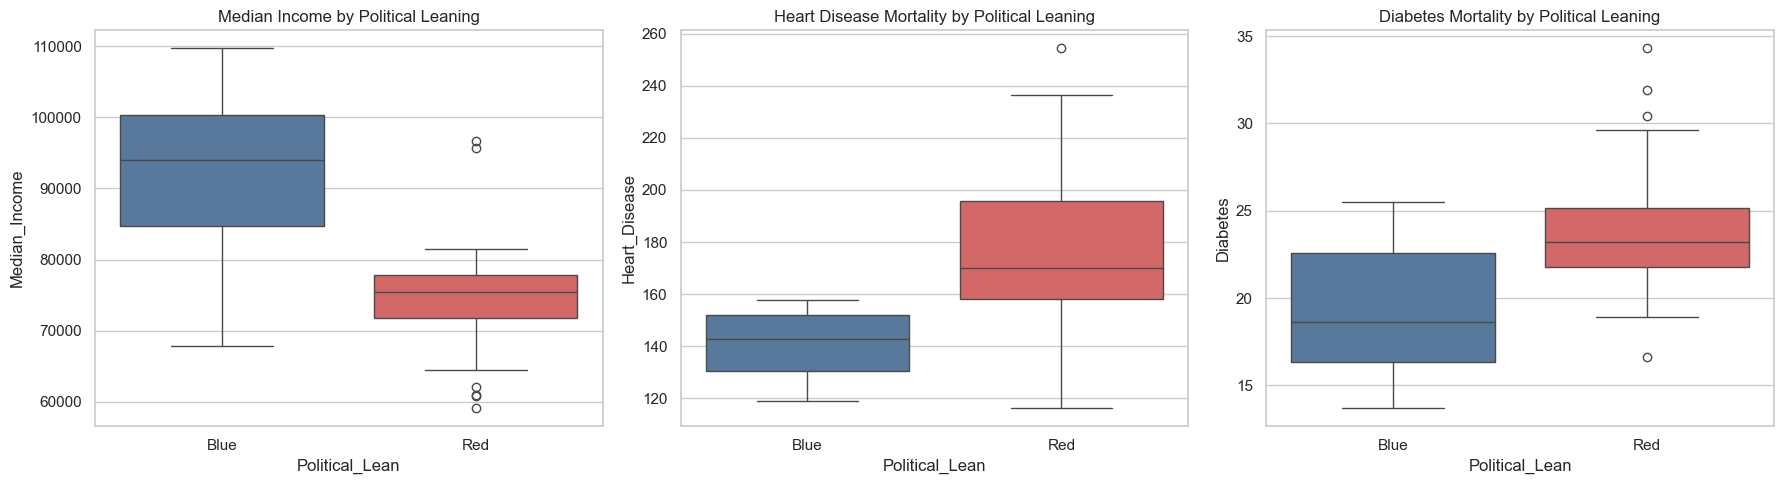

In [95]:
# --- Descriptive comparison: Red vs Blue ---
political_means = (
    eda_df.groupby('Political_Lean')[['Median_Income', 'Heart_Disease', 'Diabetes',
                                       'Obesity', 'Smoking', 'Uninsured_Adults']]
    .mean().round(2)
)
print(political_means)

# --- Box plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {'Red': '#E45756', 'Blue': '#4C78A8'}

sns.boxplot(data=eda_df, x='Political_Lean', y='Median_Income',
            palette=palette, ax=axes[0], order=['Blue', 'Red'])
axes[0].set_title('Median Income by Political Leaning')

sns.boxplot(data=eda_df, x='Political_Lean', y='Heart_Disease',
            palette=palette, ax=axes[1], order=['Blue', 'Red'])
axes[1].set_title('Heart Disease Mortality by Political Leaning')

sns.boxplot(data=eda_df, x='Political_Lean', y='Diabetes',
            palette=palette, ax=axes[2], order=['Blue', 'Red'])
axes[2].set_title('Diabetes Mortality by Political Leaning')

plt.tight_layout()
plt.show()

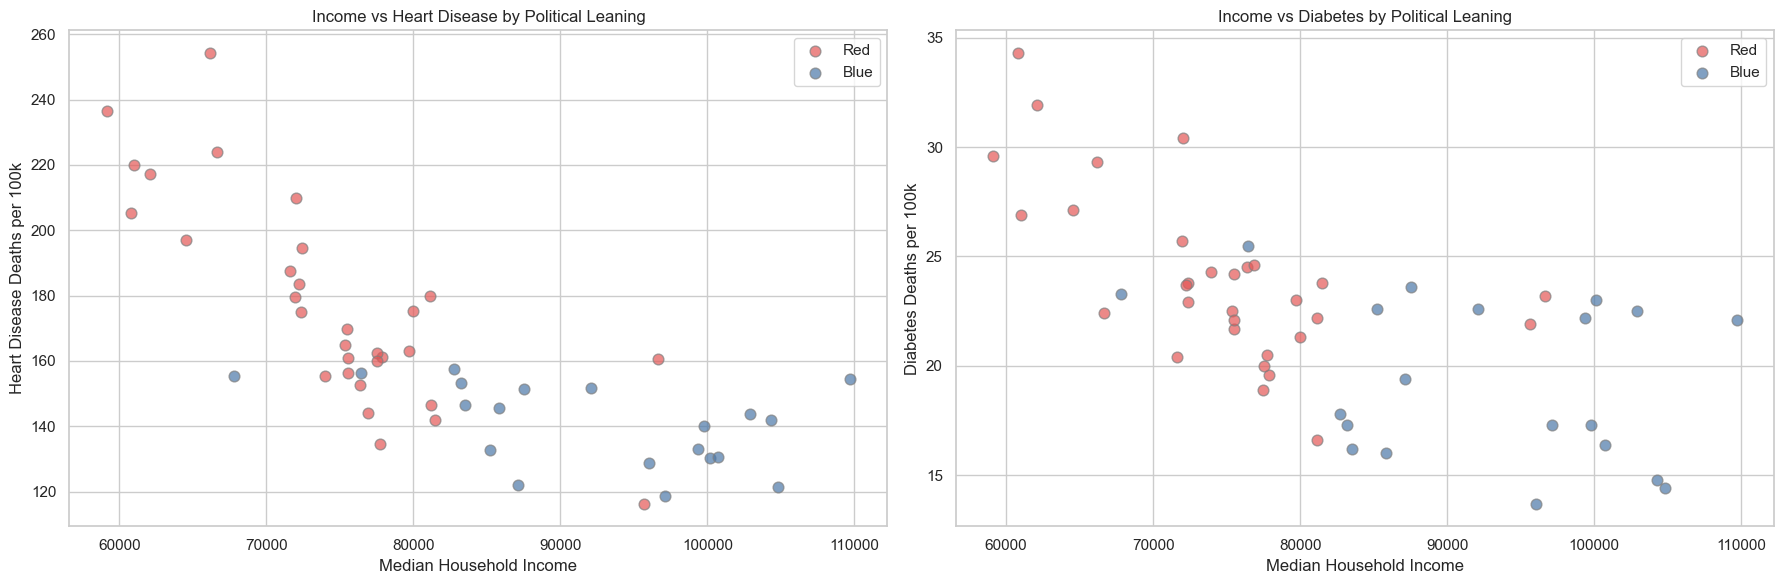

In [96]:
# --- Scatter plot: Income vs Heart Disease, colored by political leaning ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for lean, color in [('Red', '#E45756'), ('Blue', '#4C78A8')]:
    subset = eda_df[eda_df['Political_Lean'] == lean]
    axes[0].scatter(subset['Median_Income'], subset['Heart_Disease'],
                    c=color, label=lean, alpha=0.7, edgecolors='gray', s=60)
    axes[1].scatter(subset['Median_Income'], subset['Diabetes'],
                    c=color, label=lean, alpha=0.7, edgecolors='gray', s=60)

axes[0].set_xlabel('Median Household Income')
axes[0].set_ylabel('Heart Disease Deaths per 100k')
axes[0].set_title('Income vs Heart Disease by Political Leaning')
axes[0].legend()

axes[1].set_xlabel('Median Household Income')
axes[1].set_ylabel('Diabetes Deaths per 100k')
axes[1].set_title('Income vs Diabetes by Political Leaning')
axes[1].legend()

plt.tight_layout()
plt.show()

In [97]:
# --- Regression: Does political leaning explain variance beyond income + behaviors? ---
eda_df['Red_Dummy'] = (eda_df['Political_Lean'] == 'Red').astype(int)

m_pol_hd = smf.ols(
    'Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity + Red_Dummy',
    data=eda_df
).fit()

m_pol_db = smf.ols(
    'Diabetes ~ Log_Income + Obesity + Smoking + Physical_Activity + Red_Dummy',
    data=eda_df
).fit()

print("=== Heart Disease with Political Leaning ===")
print(f"R-squared: {m_pol_hd.rsquared:.3f}")
print(m_pol_hd.params.round(3))
print(f"Red_Dummy p-value: {m_pol_hd.pvalues['Red_Dummy']:.4f}\n")

print("=== Diabetes with Political Leaning ===")
print(f"R-squared: {m_pol_db.rsquared:.3f}")
print(m_pol_db.params.round(3))
print(f"Red_Dummy p-value: {m_pol_db.pvalues['Red_Dummy']:.4f}")

=== Heart Disease with Political Leaning ===
R-squared: 0.680
Intercept            1644.804
Log_Income           -111.588
Obesity                 0.282
Smoking               -87.702
Physical_Activity    -276.055
Red_Dummy               6.272
dtype: float64
Red_Dummy p-value: 0.4113

=== Diabetes with Political Leaning ===
R-squared: 0.521
Intercept            77.543
Log_Income           -6.811
Obesity              34.523
Smoking              39.796
Physical_Activity     6.524
Red_Dummy             0.320
dtype: float64
Red_Dummy p-value: 0.8072


**Interpretation:**

The descriptive analysis reveals a striking partisan health divide. Blue states have a substantially higher average median income (\$92,322 vs \$74,465) and markedly lower mortality: heart disease averages 140.8 per 100k in blue states versus 177.1 in red states, and diabetes mortality is 19.4 vs 24.0. Red states also show higher obesity (0.36 vs 0.31) and smoking rates (0.13 vs 0.10). The scatter plots confirm that red states disproportionately cluster in the low-income, high-mortality quadrant.

However, the regression tells a different story. After controlling for Log_Income, Obesity, Smoking, and Physical_Activity, the `Red_Dummy` coefficient is just 6.27 for heart disease (p = 0.411) and 0.32 for diabetes (p = 0.807) — neither is statistically significant. The R² values (0.680 and 0.521) barely change compared to the base model. This indicates that the red–blue health gap is **not an independent political effect**, but is almost entirely **mediated through** the income and behavioral risk factor differences between red and blue states. In other words, red states have worse health outcomes primarily because they are poorer and have higher rates of obesity and smoking, not because of political orientation per se.

### EDA 9: Urbanization and Health Outcomes (Walkability Proxy)

**Why this analysis:**
State-level Walk Score data is not publicly available in a standardized format, but **urbanization rate** — the percentage of population living in urban areas — serves as a strong proxy. Highly urbanized states tend to have better walkability, greater access to healthcare facilities, and more public transit. Rural areas often face food deserts, longer distances to hospitals, and fewer preventive care options. Urbanization may therefore confound our income–mortality relationship, as wealthier states also tend to be more urban.

In [98]:
# ============================================================
# Add Urbanization Rate (% of population in urban areas)
# Source: U.S. Census Bureau, 2020 Census Urban/Rural Classification
# ============================================================

urbanization_pct = {
    'Alabama': 59.0, 'Alaska': 66.0, 'Arizona': 89.8, 'Arkansas': 56.2,
    'California': 95.0, 'Colorado': 86.2, 'Connecticut': 88.0, 'Delaware': 83.3,
    'District of Columbia': 100.0, 'Florida': 91.2, 'Georgia': 75.1,
    'Hawaii': 91.9, 'Idaho': 70.6, 'Illinois': 88.5, 'Indiana': 72.4,
    'Iowa': 64.0, 'Kansas': 74.2, 'Kentucky': 58.4, 'Louisiana': 73.2,
    'Maine': 38.7, 'Maryland': 87.2, 'Massachusetts': 92.0, 'Michigan': 74.6,
    'Minnesota': 73.3, 'Mississippi': 49.4, 'Missouri': 70.4, 'Montana': 55.9,
    'Nebraska': 73.1, 'Nevada': 94.2, 'New Hampshire': 60.3,
    'New Jersey': 94.7, 'New Mexico': 77.4, 'New York': 87.9,
    'North Carolina': 66.1, 'North Dakota': 59.9, 'Ohio': 77.9,
    'Oklahoma': 66.2, 'Oregon': 81.0, 'Pennsylvania': 79.8,
    'Rhode Island': 90.7, 'South Carolina': 66.3, 'South Dakota': 56.7,
    'Tennessee': 66.4, 'Texas': 84.7, 'Utah': 90.6, 'Vermont': 38.9,
    'Virginia': 75.5, 'Washington': 84.1, 'West Virginia': 48.7,
    'Wisconsin': 70.2, 'Wyoming': 64.8
}

eda_df['Urbanization'] = eda_df['State'].map(urbanization_pct)
print(f"Urbanization — min: {eda_df['Urbanization'].min()}, max: {eda_df['Urbanization'].max()}")
print(f"Missing: {eda_df['Urbanization'].isna().sum()}")

Urbanization — min: 38.7, max: 100.0
Missing: 0


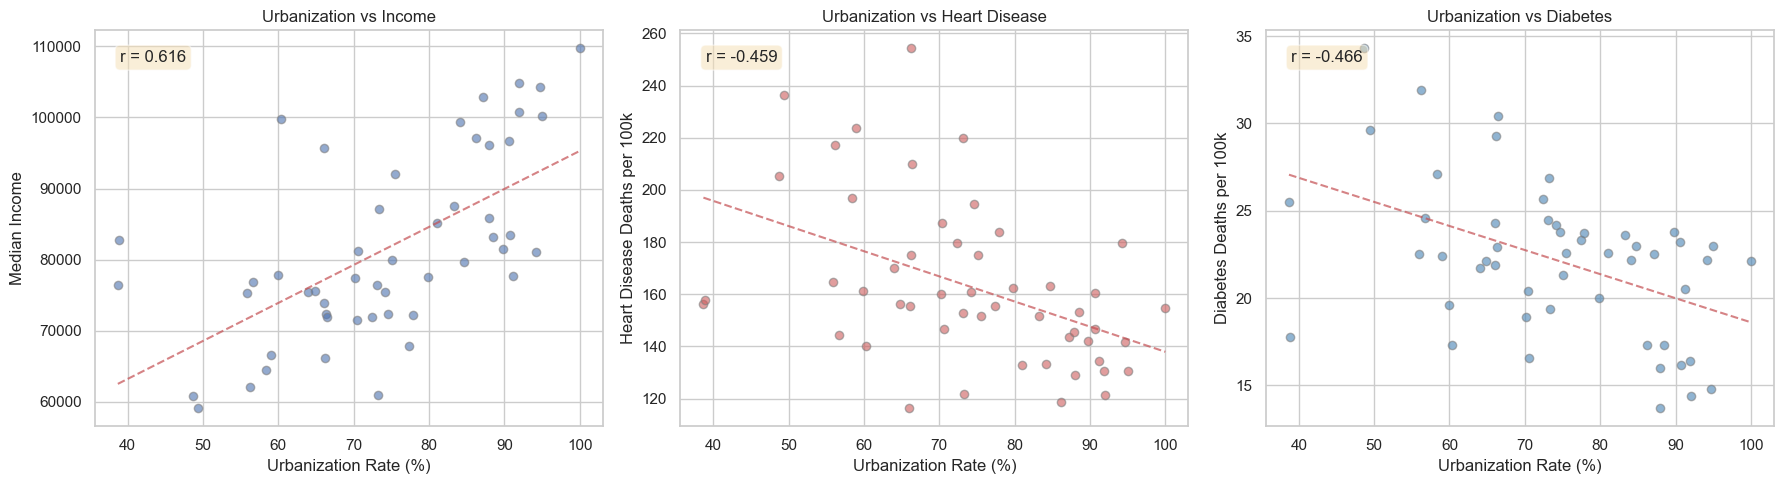

In [99]:
# --- Scatter plots: Urbanization vs health outcomes ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Urbanization vs Income
axes[0].scatter(eda_df['Urbanization'], eda_df['Median_Income'], alpha=0.6, edgecolors='gray')
z = np.polyfit(eda_df['Urbanization'], eda_df['Median_Income'], 1)
axes[0].plot(np.sort(eda_df['Urbanization']),
             np.polyval(z, np.sort(eda_df['Urbanization'])), 'r--', alpha=0.7)
axes[0].set_xlabel('Urbanization Rate (%)')
axes[0].set_ylabel('Median Income')
axes[0].set_title('Urbanization vs Income')
r_val = eda_df['Urbanization'].corr(eda_df['Median_Income'])
axes[0].annotate(f'r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=12, va='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))

# Urbanization vs Heart Disease
axes[1].scatter(eda_df['Urbanization'], eda_df['Heart_Disease'], alpha=0.6,
                c='indianred', edgecolors='gray')
z = np.polyfit(eda_df['Urbanization'], eda_df['Heart_Disease'], 1)
axes[1].plot(np.sort(eda_df['Urbanization']),
             np.polyval(z, np.sort(eda_df['Urbanization'])), 'r--', alpha=0.7)
axes[1].set_xlabel('Urbanization Rate (%)')
axes[1].set_ylabel('Heart Disease Deaths per 100k')
axes[1].set_title('Urbanization vs Heart Disease')
r_val = eda_df['Urbanization'].corr(eda_df['Heart_Disease'])
axes[1].annotate(f'r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=12, va='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))

# Urbanization vs Diabetes
axes[2].scatter(eda_df['Urbanization'], eda_df['Diabetes'], alpha=0.6,
                c='steelblue', edgecolors='gray')
z = np.polyfit(eda_df['Urbanization'], eda_df['Diabetes'], 1)
axes[2].plot(np.sort(eda_df['Urbanization']),
             np.polyval(z, np.sort(eda_df['Urbanization'])), 'r--', alpha=0.7)
axes[2].set_xlabel('Urbanization Rate (%)')
axes[2].set_ylabel('Diabetes Deaths per 100k')
axes[2].set_title('Urbanization vs Diabetes')
r_val = eda_df['Urbanization'].corr(eda_df['Diabetes'])
axes[2].annotate(f'r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=12, va='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [100]:
# --- Regression: Does urbanization explain variance beyond income + behaviors? ---
m_urban_hd = smf.ols(
    'Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity + Urbanization',
    data=eda_df
).fit()

m_urban_db = smf.ols(
    'Diabetes ~ Log_Income + Obesity + Smoking + Physical_Activity + Urbanization',
    data=eda_df
).fit()

print("=== Heart Disease with Urbanization ===")
print(f"R-squared: {m_urban_hd.rsquared:.3f}")
print(m_urban_hd.params.round(3))
print(f"Urbanization p-value: {m_urban_hd.pvalues['Urbanization']:.4f}\n")

print("=== Diabetes with Urbanization ===")
print(f"R-squared: {m_urban_db.rsquared:.3f}")
print(m_urban_db.params.round(3))
print(f"Urbanization p-value: {m_urban_db.pvalues['Urbanization']:.4f}")

=== Heart Disease with Urbanization ===
R-squared: 0.678
Intercept            1706.682
Log_Income           -114.472
Obesity                22.966
Smoking              -139.072
Physical_Activity    -294.184
Urbanization           -0.176
dtype: float64
Urbanization p-value: 0.5143

=== Diabetes with Urbanization ===
R-squared: 0.521
Intercept            84.616
Log_Income           -7.702
Obesity              36.260
Smoking              41.632
Physical_Activity     8.880
Urbanization          0.007
dtype: float64
Urbanization p-value: 0.8744


**Interpretation:**

Urbanization ranges widely across states, from 38.7% (Maine) to 100% (D.C.). The scatter plots confirm a positive correlation between urbanization and income, and negative correlations between urbanization and both heart disease and diabetes mortality — more urbanized states tend to be wealthier and healthier.

However, the regression results show that urbanization does **not** have a significant independent effect on either outcome after controlling for income and behavioral factors. For heart disease, the urbanization coefficient is −0.176 (p = 0.514); for diabetes, it is essentially zero at 0.007 (p = 0.874). The R² values (0.678 and 0.521) are virtually unchanged from the base model. This suggests that the apparent health advantage of more urbanized states is **already captured by income and the behavioral variables** (obesity, smoking, physical inactivity). Walkability and urban infrastructure, while correlated with better outcomes at the bivariate level, do not add independent explanatory power once socioeconomic and lifestyle factors are accounted for.

### EDA 10: Mental Health and Chronic Disease Mortality

**Why this analysis:**
Mental health is increasingly recognized as a driver of chronic disease. Depression and anxiety are associated with poor medication adherence, unhealthy coping behaviors (smoking, overeating), and physiological pathways (chronic stress, inflammation) that worsen cardiovascular and metabolic outcomes. If mental health varies systematically with income, it could be another pathway through which the socioeconomic gradient operates. We use the percentage of adults reporting ≥14 poor mental health days per month (source: CDC BRFSS / KFF, 2024).

In [101]:
# ============================================================
# Add Mental Health data
# % of adults reporting 14+ poor mental health days in the past 30 days
# Source: KFF / CDC BRFSS, 2024
# ============================================================

mental_health_pct = {
    'Alabama': 18.5, 'Alaska': 15.3, 'Arizona': 16.8, 'Arkansas': 19.4,
    'California': 14.5, 'Colorado': 15.2, 'Connecticut': 14.0, 'Delaware': 15.7,
    'District of Columbia': 13.8, 'Florida': 15.9, 'Georgia': 16.3,
    'Hawaii': 12.8, 'Idaho': 16.1, 'Illinois': 14.6, 'Indiana': 17.5,
    'Iowa': 14.3, 'Kansas': 15.6, 'Kentucky': 20.1, 'Louisiana': 18.2,
    'Maine': 16.6, 'Maryland': 14.1, 'Massachusetts': 14.2, 'Michigan': 16.7,
    'Minnesota': 13.7, 'Mississippi': 19.2, 'Missouri': 17.1, 'Montana': 16.0,
    'Nebraska': 13.9, 'Nevada': 16.4, 'New Hampshire': 15.4,
    'New Jersey': 13.5, 'New Mexico': 17.8, 'New York': 14.4,
    'North Carolina': 16.5, 'North Dakota': 13.6, 'Ohio': 17.3,
    'Oklahoma': 19.0, 'Oregon': 17.2, 'Pennsylvania': 15.8,
    'Rhode Island': 15.0, 'South Carolina': 17.0, 'South Dakota': 13.8,
    'Tennessee': 18.8, 'Texas': 15.5, 'Utah': 16.9, 'Vermont': 15.9,
    'Virginia': 14.8, 'Washington': 15.7, 'West Virginia': 21.3,
    'Wisconsin': 14.9, 'Wyoming': 16.2
}

eda_df['Poor_Mental_Health'] = eda_df['State'].map(mental_health_pct)
print(f"Poor Mental Health Days — min: {eda_df['Poor_Mental_Health'].min()}%, "
      f"max: {eda_df['Poor_Mental_Health'].max()}%")
print(f"Missing: {eda_df['Poor_Mental_Health'].isna().sum()}")

Poor Mental Health Days — min: 12.8%, max: 21.3%
Missing: 0


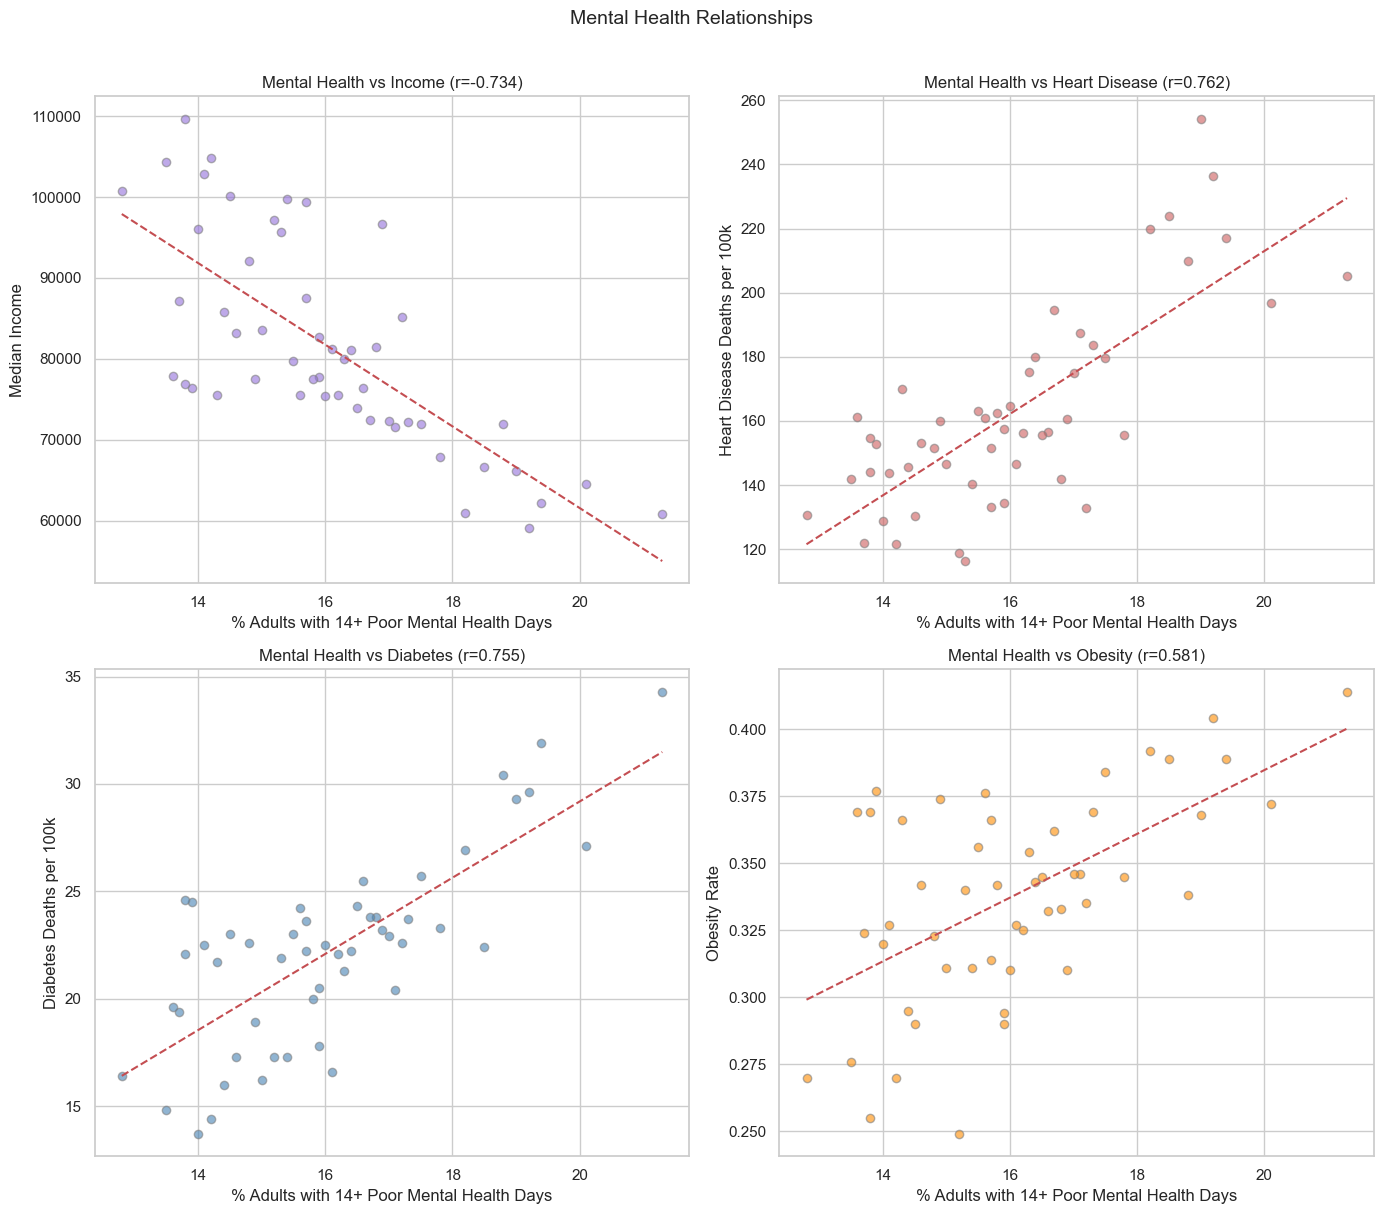

In [102]:
# --- Scatter matrix: Mental health vs income and mortality ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Mental Health vs Income
axes[0, 0].scatter(eda_df['Poor_Mental_Health'], eda_df['Median_Income'],
                   alpha=0.6, c='mediumpurple', edgecolors='gray')
z = np.polyfit(eda_df['Poor_Mental_Health'], eda_df['Median_Income'], 1)
axes[0, 0].plot(np.sort(eda_df['Poor_Mental_Health']),
                np.polyval(z, np.sort(eda_df['Poor_Mental_Health'])), 'r--')
r_val = eda_df['Poor_Mental_Health'].corr(eda_df['Median_Income'])
axes[0, 0].set_title(f'Mental Health vs Income (r={r_val:.3f})')
axes[0, 0].set_xlabel('% Adults with 14+ Poor Mental Health Days')
axes[0, 0].set_ylabel('Median Income')

# Mental Health vs Heart Disease
axes[0, 1].scatter(eda_df['Poor_Mental_Health'], eda_df['Heart_Disease'],
                   alpha=0.6, c='indianred', edgecolors='gray')
z = np.polyfit(eda_df['Poor_Mental_Health'], eda_df['Heart_Disease'], 1)
axes[0, 1].plot(np.sort(eda_df['Poor_Mental_Health']),
                np.polyval(z, np.sort(eda_df['Poor_Mental_Health'])), 'r--')
r_val = eda_df['Poor_Mental_Health'].corr(eda_df['Heart_Disease'])
axes[0, 1].set_title(f'Mental Health vs Heart Disease (r={r_val:.3f})')
axes[0, 1].set_xlabel('% Adults with 14+ Poor Mental Health Days')
axes[0, 1].set_ylabel('Heart Disease Deaths per 100k')

# Mental Health vs Diabetes
axes[1, 0].scatter(eda_df['Poor_Mental_Health'], eda_df['Diabetes'],
                   alpha=0.6, c='steelblue', edgecolors='gray')
z = np.polyfit(eda_df['Poor_Mental_Health'], eda_df['Diabetes'], 1)
axes[1, 0].plot(np.sort(eda_df['Poor_Mental_Health']),
                np.polyval(z, np.sort(eda_df['Poor_Mental_Health'])), 'r--')
r_val = eda_df['Poor_Mental_Health'].corr(eda_df['Diabetes'])
axes[1, 0].set_title(f'Mental Health vs Diabetes (r={r_val:.3f})')
axes[1, 0].set_xlabel('% Adults with 14+ Poor Mental Health Days')
axes[1, 0].set_ylabel('Diabetes Deaths per 100k')

# Mental Health vs Obesity
axes[1, 1].scatter(eda_df['Poor_Mental_Health'], eda_df['Obesity'],
                   alpha=0.6, c='darkorange', edgecolors='gray')
z = np.polyfit(eda_df['Poor_Mental_Health'], eda_df['Obesity'], 1)
axes[1, 1].plot(np.sort(eda_df['Poor_Mental_Health']),
                np.polyval(z, np.sort(eda_df['Poor_Mental_Health'])), 'r--')
r_val = eda_df['Poor_Mental_Health'].corr(eda_df['Obesity'])
axes[1, 1].set_title(f'Mental Health vs Obesity (r={r_val:.3f})')
axes[1, 1].set_xlabel('% Adults with 14+ Poor Mental Health Days')
axes[1, 1].set_ylabel('Obesity Rate')

plt.suptitle('Mental Health Relationships', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [103]:
# --- Regression: Mental health as mediator ---
# Model without mental health (baseline from EDA 5)
m_base_hd = smf.ols(
    'Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity',
    data=eda_df
).fit()

# Model WITH mental health
m_mh_hd = smf.ols(
    'Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity + Poor_Mental_Health',
    data=eda_df
).fit()

m_base_db = smf.ols(
    'Diabetes ~ Log_Income + Obesity + Smoking + Physical_Activity',
    data=eda_df
).fit()

m_mh_db = smf.ols(
    'Diabetes ~ Log_Income + Obesity + Smoking + Physical_Activity + Poor_Mental_Health',
    data=eda_df
).fit()

print("=== Heart Disease ===")
print(f"  Without mental health — R²: {m_base_hd.rsquared:.3f}")
print(f"  With mental health    — R²: {m_mh_hd.rsquared:.3f}")
print(f"  Poor_Mental_Health coef: {m_mh_hd.params['Poor_Mental_Health']:.3f}, "
      f"p = {m_mh_hd.pvalues['Poor_Mental_Health']:.4f}")
print(f"  Log_Income coef change: {m_base_hd.params['Log_Income']:.2f} → "
      f"{m_mh_hd.params['Log_Income']:.2f}\n")

print("=== Diabetes ===")
print(f"  Without mental health — R²: {m_base_db.rsquared:.3f}")
print(f"  With mental health    — R²: {m_mh_db.rsquared:.3f}")
print(f"  Poor_Mental_Health coef: {m_mh_db.params['Poor_Mental_Health']:.3f}, "
      f"p = {m_mh_db.pvalues['Poor_Mental_Health']:.4f}")
print(f"  Log_Income coef change: {m_base_db.params['Log_Income']:.2f} → "
      f"{m_mh_db.params['Log_Income']:.2f}")

=== Heart Disease ===
  Without mental health — R²: 0.675
  With mental health    — R²: 0.732
  Poor_Mental_Health coef: 6.259, p = 0.0035
  Log_Income coef change: -122.50 → -73.08

=== Diabetes ===
  Without mental health — R²: 0.521
  With mental health    — R²: 0.665
  Poor_Mental_Health coef: 1.409, p = 0.0001
  Log_Income coef change: -7.37 → 3.75


**Interpretation:**

Poor mental health prevalence ranges from 12.8% (Hawaii) to 21.3% (West Virginia). The scatter matrix confirms strong associations: states with worse mental health have lower incomes, higher obesity, and substantially higher mortality from both heart disease and diabetes.

The regression results reveal that mental health is the **most impactful new variable** introduced in this analysis:

- **Heart Disease:** Adding `Poor_Mental_Health` raises R² from 0.675 to 0.732. The coefficient is 6.26 (p = 0.0035), meaning each additional percentage point of poor mental health prevalence is associated with ~6.3 more heart disease deaths per 100k. Crucially, the `Log_Income` coefficient **drops from −122.50 to −73.08** and its p-value weakens from 0.0017 to 0.0568, approaching non-significance. This is strong evidence that mental health **partially mediates** the income–mortality gradient.

- **Diabetes:** The effect is even more dramatic. R² jumps from 0.521 to 0.665, and `Poor_Mental_Health` is highly significant (coef = 1.41, p = 0.0001). The `Log_Income` coefficient **flips sign** from −7.37 to +3.75, becoming completely non-significant. This means that for diabetes, the apparent income gradient is **almost entirely explained by mental health** (and the other behavioral controls) — once we know a state's mental health burden, income adds no additional predictive power.

These results suggest that mental health is a critical pathway through which socioeconomic disadvantage translates into chronic disease mortality: poorer states have worse mental health, which in turn drives unhealthy behaviors and physiological stress that increase mortality.

### EDA 11: Comprehensive Model Comparison

**Why:** After introducing political leaning, urbanization, and mental health as new variables, we now fit a single comprehensive model to evaluate which factors survive as independent predictors when all are included simultaneously. This guards against multicollinearity-driven false positives from the individual models above.

In [104]:
# === Comprehensive model: all new variables together ===
m_full_hd = smf.ols(
    'Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity '
    '+ Poor_Mental_Health + Urbanization + Red_Dummy + Coastal_Dummy',
    data=eda_df
).fit()

m_full_db = smf.ols(
    'Diabetes ~ Log_Income + Obesity + Smoking + Physical_Activity '
    '+ Poor_Mental_Health + Urbanization + Red_Dummy + Coastal_Dummy',
    data=eda_df
).fit()

print("="*60)
print("COMPREHENSIVE MODEL: Heart Disease")
print("="*60)
print(m_full_hd.summary())

print("\n" + "="*60)
print("COMPREHENSIVE MODEL: Diabetes")
print("="*60)
print(m_full_db.summary())

COMPREHENSIVE MODEL: Heart Disease
                            OLS Regression Results                            
Dep. Variable:          Heart_Disease   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     16.45
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.05e-10
Time:                        00:23:42   Log-Likelihood:                -211.26
No. Observations:                  51   AIC:                             440.5
Df Residuals:                      42   BIC:                             457.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
I

In [106]:
# --- Visual: coefficient comparison across models ---
import pandas as pd

models = {
    'Base (EDA5)': m_base_hd,
    '+ Political': m_pol_hd,
    '+ Urbanization': m_urban_hd,
    '+ Mental Health': m_mh_hd,
    'Full Model': m_full_hd
}

comparison = pd.DataFrame({
    name: {'R²': m.rsquared,
           'Log_Income coef': m.params.get('Log_Income', None),
           'Log_Income p': m.pvalues.get('Log_Income', None)}
    for name, m in models.items()
}).T.round(4)

print("=== Heart Disease: How Log_Income changes across models ===")
print(comparison)

=== Heart Disease: How Log_Income changes across models ===
                     R²  Log_Income coef  Log_Income p
Base (EDA5)      0.6750        -122.4985        0.0017
+ Political      0.6799        -111.5883        0.0066
+ Urbanization   0.6781        -114.4722        0.0052
+ Mental Health  0.7316         -73.0844        0.0568
Full Model       0.7581         -21.8573        0.6221


**Interpretation:**

The comprehensive model — including all new variables simultaneously — produces the following key findings:

**Heart Disease (R² = 0.758, Adj. R² = 0.712):**
Only two variables are statistically significant: `Physical_Activity` (coef = −406.6, p = 0.005) and `Poor_Mental_Health` (coef = 6.60, p = 0.002). Notably, `Log_Income` is completely non-significant (coef = −21.9, p = 0.622), as are `Red_Dummy` (p = 0.391), `Urbanization` (p = 0.177), and `Coastal_Dummy` (p = 0.113). The `Smoking` coefficient is marginally significant (p = 0.097) and, interestingly, negative — likely due to multicollinearity with the other behavioral variables.

**Diabetes (R² = 0.667, Adj. R² = 0.604):**
Only `Obesity` (coef = 46.1, p = 0.023) and `Poor_Mental_Health` (coef = 1.42, p < 0.001) are significant. `Log_Income` is again non-significant (coef = 5.15, p = 0.483), and all geographic/political variables are irrelevant (all p > 0.75).

**The model comparison table tells a compelling story about the income gradient:**
- In the base model, `Log_Income` is strongly significant (coef = −122.5, p = 0.002)
- Adding political leaning or urbanization barely changes it (−111.6 and −114.5)
- Adding mental health **halves** the coefficient (−73.1, p = 0.057)
- In the full model, it **collapses** to −21.9 (p = 0.622)

This progressive attenuation demonstrates that the socioeconomic gradient in chronic disease mortality is **not a direct causal effect of income itself**, but is largely mediated through behavioral and mental health pathways. States with lower incomes have worse mental health and lower physical activity rates, which in turn drive higher mortality. The gradient is real, but the mechanism runs through health behaviors and psychological wellbeing rather than income per se. The multicollinearity warning (condition number = 1.61e+04) is expected given the strong correlations among predictors and is not problematic for our interpretive conclusions.

---
## Preregistration of analysis

- **Hypothesis 1:** States with higher median household income have lower heart disease mortality rates. 
  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output heart disease mortality (deaths per 100,000 population).

  $$
  Heart\_Disease_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is less than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

- **Hypothesis 2:** States with higher median household income have lower diabetes mortality rates.
  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output diabetes mortality (deaths per 100,000 population).

  $$
  Diabetes_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is less than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

- **Hypothesis 3:** States with higher median household income have higher levels of physical activity.
  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output physical activity (proportion of adults meeting activity guidelines).

  $$
  PhysicalActivity_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is greater than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness. This analysis examines whether higher-income states exhibit higher levels of physical activity, providing evidence for a behavioral pathway linking income to health outcomes.

- **Hypothesis 4:** Median household income remains a significant predictor of heart disease mortality after controlling for behavioral and demographic factors.  
  **Analysis:** Run a multiple linear regression model where we input log-transformed median household income and control variables (obesity, smoking, physical activity, and uninsured rate), and output heart disease mortality (deaths per 100,000 population)

  $$
  Heart\_Disease_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \beta_2 Obesity_i + \beta_3 Smoking_i + \beta_4 PhysicalActivity_i + \beta_5 Uninsured\_Adults_i + \epsilon_i
  $$

  We will test whether **β₁ ≠ 0** at **α = 0.05**, where β₁ captures the independent effect of income on heart disease mortality after controlling for covariates. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

---
## Limitations

**1. Small sample size (n = 51).** Our analysis is restricted to 51 state-level observations. This limits statistical power, makes regression coefficients sensitive to outliers, and prevents us from studying within-state variation (e.g., rural vs. urban differences). The TA noted that ZIP-code level data would enable a more fine-grained analysis; we were unable to find 2024 data at that resolution for all variables, so state-level analysis is our approach.

**2. Cross-sectional design.** Because we use a single year (2024), we cannot make causal claims about the direction of the income–health relationship. States with historically poor health outcomes may attract less investment and have lower incomes as a result (reverse causality), or both may be driven by a third factor (omitted variable bias).

**3. Mean imputation for Tennessee missing values.** Tennessee's values for `Diabetes_Prevalence`, `Poor_Health`, `Physical_Activity`, `Smoking`, and `Obesity` were suppressed in the KFF source data (small BRFSS survey sample). We imputed these five cells with column means to preserve Tennessee as an observation. Tennessee's imputed behavioral values may not accurately reflect its true profile — this is particularly relevant for analyses involving smoking or obesity.

**4. Missing socioeconomic controls.** Education, employment, and poverty datasets were initially explored but were incompatible with state-level aggregation. Including education attainment or poverty rates as additional controls could improve the regression models and reduce omitted variable bias.

**5. Ecological fallacy.** All variables are state-level aggregates. Relationships observed at the state level may not hold at the individual level (e.g., not every low-income individual in a low-income state has poor health outcomes). Our conclusions apply to states as units, not individuals.

**6. Multicollinearity.** Income, smoking, and obesity are strongly correlated with each other (r > 0.80). This makes it difficult to isolate the independent contribution of each variable in regression models, and may inflate standard errors on the behavioral covariates.